## Vectorielles : résolution temporelle fine (10ms), capture le moment exact où la population s'aligne sur l'axe CD, adapté pour détecter des événements précis
## Matricielles : intègrent le pattern spatiotemporel sur 100ms, plus robustes au bruit trial-to-trial mais moins précises temporellement

### **On définit le threshold optimal comme celui qui maximise `P(lick|détection stim) - P(lick|détection ITI)`, c'est-à-dire le threshold auquel le score CD discrimine le mieux les événements perçus par la souris (détections stim suivies de licks) des activités spontanées non-perçues (bursts ITI non suivis de licks), en utilisant le comportement réel de la souris comme ground truth.**

In [20]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import find_peaks
from scipy.ndimage import gaussian_filter1d
from scipy.stats import wilcoxon
from pynwb import NWBHDF5IO
import ipywidgets as widgets
from IPython.display import display

# ── Paramètres globaux ──────────────────────────────────────────────────────
THIS_AREA     = 'wS1'
Bin_size      = 0.01
AP_Bin_Res    = 1.0 / Bin_size
pre_bins      = 50
post_bins     = 100
amps_stim     = [1, 2, 3, 4]
tol_post      = 0.05
refractory_s  = 0.3
lick_window_s = 1.0
N_PCT         = 200
pct_axis      = np.linspace(1, 99.9, N_PCT)
time_axis     = (np.arange(pre_bins + post_bins + 1) - pre_bins) * Bin_size
colors_amp    = {1: 'gold', 2: 'orange', 3: 'tomato', 4: 'red'}

# ── Paramètres Coding Direction ─────────────────────────────────────────────
CD_USE_AMP    = 4
CD_METHOD     = 'projection'   # 'projection', 'cosine', 'euclidean', 'matrix_cosine', 'matrix_euclidean'
CD_WINDOW     = (50, 55)       # fenêtre unique pour CD vectorielle simple (PSTH centré, 50 = stimulus)
CD_WINDOWS_2  = [(0, 4), (6, 15)]  # fenêtres post-stim en offsets pour la CD matrix/template

CD_PRE_BASELINE     = 10
CD_MATRIX_STEP_BINS = 1
CD_MATRIX_ZSCORE    = True

CD_METHODS = [
    'projection',
    'cosine',
    'euclidean',
    'matrix_cosine',
    'matrix_euclidean',
]

CI95 = lambda arr, axis=0: np.std(arr, axis=axis, ddof=1)  # SD across sessions
print('Imports OK')


Imports OK


In [21]:
import glob, os

# ── Scan automatique de data/valid/WR+/ et data/valid/WR-/ ─────────────────
VALID_BASE    = 'data/valid'
GROUPS        = ['WR+', 'WR-']

SESSION_PATHS = []
for _grp in GROUPS:
    _grp_dir = os.path.join(VALID_BASE, _grp)
    SESSION_PATHS.extend(sorted(glob.glob(os.path.join(_grp_dir, '*.nwb'))))

print(f'{len(SESSION_PATHS)} session(s) trouvee(s) dans {VALID_BASE}/ :')
for p in SESSION_PATHS:
    grp = p.split('/')[-2]
    print(f'  [{grp}]  {os.path.basename(p)}')


9 session(s) trouvee(s) dans data/valid/ :
  [WR+]  AO026_20181122_180943.nwb
  [WR+]  AO027_20181101_134512.nwb
  [WR+]  AO028_20181102_110339.nwb
  [WR+]  AO036_20190507_183647.nwb
  [WR+]  AO039_20190626_160524.nwb
  [WR+]  AO040_20190708_124008.nwb
  [WR+]  AO049_20191009_160435.nwb
  [WR+]  AO050_20191007_195438.nwb
  [WR+]  AO051_20191004_182709.nwb


In [22]:
# ── Helpers ────────────────────────────────────────────────────────────────

def event_triggered_mean(M, event_times, res, pre=50, post=100):
    W   = pre + post + 1
    acc = np.zeros((M.shape[0], W), dtype=np.float32)
    n   = 0
    for ev in event_times:
        pt = int(np.round(ev * res))
        if pt - pre < 0 or pt + post >= M.shape[1]:
            continue
        acc += M[:, pt - pre: pt + post + 1]
        n   += 1
    return acc / max(n, 1), n

def detect_peaks_fn(score, t, thr, refrac, bin_s, t0, t1):
    score = np.asarray(score)
    t     = np.asarray(t)
    mask = np.isfinite(score) & (t >= t0) & (t <= t1) & (score > thr)
    idx  = np.where(mask)[0]
    if idx.size == 0:
        return np.array([], dtype=float)
    cuts   = np.where(np.diff(idx) > 1)[0] + 1
    groups = np.split(idx, cuts)
    peaks  = np.array([g[np.argmax(score[g])] for g in groups], dtype=int)
    min_b  = max(1, int(np.ceil(refrac / bin_s)))
    keep   = [peaks[0]]
    for p in peaks[1:]:
        if p - keep[-1] >= min_b:
            keep.append(p)
        elif score[p] > score[keep[-1]]:
            keep[-1] = p
    return t[np.array(keep, dtype=int)]

def _normalize_vec(v):
    return v / (np.linalg.norm(v) + 1e-12)

def zscore_vector(v, eps=1e-10):
    v = np.asarray(v, dtype=np.float32)
    mu = np.mean(v)
    sd = np.std(v)
    return (v - mu) / (sd + eps)

def flatten(mat):
    return mat.reshape(-1).astype(np.float32)

# ── CD vectorielle simple ───────────────────────────────────────────────────
def build_cd_vector(STM_by_amp, CATCH_M, amp=4, win=(50, 55)):
    i0, i1 = win
    cd = STM_by_amp[amp][:, i0:i1].mean(axis=1) - CATCH_M[:, i0:i1].mean(axis=1)
    return _normalize_vec(cd)

# ── CD matrix / template (logique CDMatrix_MH031) ──────────────────────────
def extract_two_window_matrix(AP, event_time, resolution, win1, win2, pre_baseline):
    pt = int(np.round(event_time * resolution))
    if pt - pre_baseline < 0 or pt + max(win1[1], win2[1]) >= AP.shape[1]:
        return None

    seg1 = AP[:, pt + win1[0]: pt + win1[1]]
    seg2 = AP[:, pt + win2[0]: pt + win2[1]]

    if seg1.shape[1] == 0 or seg2.shape[1] == 0:
        return None

    mat = np.concatenate([seg1, seg2], axis=1)
    baseline = AP[:, pt - pre_baseline: pt].mean(axis=1, keepdims=True)
    mat = mat - baseline
    return mat.astype(np.float32)

def build_stack(AP, times, resolution, win1, win2, pre_baseline):
    mats = []
    kept_times = []
    for t in times:
        m = extract_two_window_matrix(AP, t, resolution, win1, win2, pre_baseline)
        if m is not None:
            mats.append(m)
            kept_times.append(t)
    if len(mats) == 0:
        return None, np.array([])
    return np.stack(mats, axis=0), np.array(kept_times)

def build_cd_matrix_template(AP_Bin, Stim_by_amp, Catch_times, res,
                             amp=4, wins=((0, 4), (6, 12)),
                             pre_baseline=10, zscore=True):
    win1, win2 = tuple(wins[0]), tuple(wins[1])

    stim_stack, stim_kept = build_stack(AP_Bin, Stim_by_amp[amp], res, win1, win2, pre_baseline)
    catch_stack, catch_kept = build_stack(AP_Bin, Catch_times,  res, win1, win2, pre_baseline)

    if stim_stack is None or len(stim_kept) == 0:
        raise ValueError(f"No valid stim windows for matrix CD (amp={amp})")

    mean_stim = stim_stack.mean(axis=0)
    if catch_stack is None or len(catch_kept) == 0:
        cd_matrix = mean_stim.copy()
        catch_mode = 'none'
    else:
        mean_catch = catch_stack.mean(axis=0)
        cd_matrix = mean_stim - mean_catch
        catch_mode = 'stim_minus_catch'

    ref_vector = flatten(cd_matrix)
    if zscore:
        ref_vector = zscore_vector(ref_vector)

    return cd_matrix, ref_vector, {
        'wins': (win1, win2),
        'pre_baseline': pre_baseline,
        'zscore': zscore,
        'n_stim_windows': len(stim_kept),
        'n_catch_windows': len(catch_kept),
        'catch_mode': catch_mode,
    }

def _score_vec(vec, ref_vector, metric, zscore_flag):
    # Cosine vs Euclidean semantic difference:
    #
    # COSINE  : measures direction match only — amplitude irrelevant.
    #   vec is zscored (unit-comparable space) then dot/norm -> pure angle.
    #   ref_vector is the zscored template direction.
    #
    # EUCLIDEAN: measures deviation in raw spike space — both direction
    #   AND amplitude matter. vec is kept raw (no zscore, no normalisation).
    #   ref_vector is unit-normalised to define the template direction.
    #   A weak response in the right direction scores lower than a strong one.
    #   High-FR units naturally dominate, which is biologically meaningful
    #   (units with larger responses carry more information).
    #
    # Mathematical guarantee: with raw vec and unit-norm ref, cosine and
    # euclidean are NOT monotone functions of each other (corr ~ 0 empirically).
    if metric in ('euclidean', 'euclidian'):
        # Raw vec, unit-norm ref -> genuinely different from cosine
        ref_n = ref_vector / (np.linalg.norm(ref_vector) + 1e-10)
        return float(-np.linalg.norm(vec - ref_n))
    elif metric == 'cosine':
        # Zscored vec, zscored ref -> direction only
        if zscore_flag:
            vec = zscore_vector(vec)
        denom = (np.linalg.norm(vec) * np.linalg.norm(ref_vector)) + 1e-10
        return float(np.dot(vec, ref_vector) / denom)
    else:
        raise ValueError(f"Unknown matrix metric: {metric}")


def _build_loo_ref(stim_stack, catch_stack, exclude_i, zscore_flag):
    """Build template leaving out stim trial index exclude_i (-1 = use all)."""
    n = stim_stack.shape[0]
    if exclude_i >= 0 and n > 1:
        keep = [j for j in range(n) if j != exclude_i]
        mean_stim = stim_stack[keep].mean(axis=0)
    else:
        mean_stim = stim_stack.mean(axis=0)
    if catch_stack is not None and len(catch_stack) > 0:
        cd = mean_stim - catch_stack.mean(axis=0)
    else:
        cd = mean_stim.copy()
    ref = flatten(cd)
    if zscore_flag:
        ref = zscore_vector(ref)
    return ref


def compute_matrix_cd_score(AP_Bin, Stim_by_amp, Catch_times, res,
                            amp=4, wins=((0, 4), (6, 12)),
                            pre_baseline=10, metric='cosine',
                            zscore=True, step_bins=1):
    """
    Matrix CD score with leave-one-out cross-validation.
    For each time point inside a stim trial window, the template is rebuilt
    excluding that trial. For ITI points the full template is used.
    This prevents in-sample overfitting of the original implementation.
    """
    win1, win2 = tuple(wins[0]), tuple(wins[1])
    step_bins  = max(1, int(step_bins))
    max_win    = max(win1[1], win2[1])

    # Build full stim/catch stacks once
    stim_stack,  stim_kept  = build_stack(AP_Bin, Stim_by_amp[amp],
                                          res, win1, win2, pre_baseline)
    catch_stack, catch_kept = build_stack(AP_Bin, Catch_times,
                                          res, win1, win2, pre_baseline)

    if stim_stack is None or len(stim_kept) == 0:
        raise ValueError(f"No valid stim windows for matrix CD (amp={amp})")

    # Stim trial bin positions for LOO lookup
    stim_pts = np.array([int(np.round(t * res)) for t in stim_kept])

    # Pre-build full template (ITI scoring) and all LOO templates
    full_ref = _build_loo_ref(stim_stack, catch_stack, -1, zscore)
    loo_refs = [_build_loo_ref(stim_stack, catch_stack, i, zscore)
                for i in range(len(stim_kept))]

    scores    = []
    valid_pts = []
    T         = AP_Bin.shape[1]

    for pt in range(pre_baseline, T - max_win, step_bins):
        mat = extract_two_window_matrix(AP_Bin, pt / res, res,
                                        win1, win2, pre_baseline)
        if mat is None:
            continue

        vec = flatten(mat)

        # LOO: find if pt falls inside any stim trial window
        trial_idx = -1
        for i, spt in enumerate(stim_pts):
            if spt <= pt < spt + max_win:
                trial_idx = i
                break

        ref = loo_refs[trial_idx] if trial_idx >= 0 else full_ref
        s   = _score_vec(vec, ref, metric, zscore)

        scores.append(s)
        valid_pts.append(pt)

    score = np.asarray(scores, dtype=np.float32)
    t_sig = np.asarray(valid_pts, dtype=np.float32) * Bin_size

    # Full template for metadata only
    if catch_stack is not None and len(catch_stack) > 0:
        cd_matrix  = stim_stack.mean(axis=0) - catch_stack.mean(axis=0)
        catch_mode = 'stim_minus_catch'
    else:
        cd_matrix  = stim_stack.mean(axis=0)
        catch_mode = 'none'

    meta = {
        'kind'            : 'matrix_template',
        'cd'              : cd_matrix,
        'ref_vector'      : full_ref,
        'method'          : f'matrix_{metric}',
        'wins'            : (win1, win2),
        'pre_baseline'    : pre_baseline,
        'zscore'          : zscore,
        'n_stim_windows'  : len(stim_kept),
        'n_catch_windows' : len(catch_kept) if catch_stack is not None else 0,
        'catch_mode'      : catch_mode,
        'step_bins'       : step_bins,
        'cross_validated' : True,
    }
    return score, t_sig, meta


# ── Interface commune pour toutes les CD ────────────────────────────────────
def compute_cd_score(AP_Bin, STM_by_amp, CATCH_M, Stim_by_amp, Catch_times, res,
                     method='projection', amp=4, win=(50, 55),
                     wins=((0, 4), (6, 12)), pre_baseline=10,
                     matrix_step_bins=1, matrix_zscore=True):
    eps = 1e-12

    if method == 'projection':
        cd = build_cd_vector(STM_by_amp, CATCH_M, amp=amp, win=win)
        score = cd @ AP_Bin
        t_sig = np.arange(AP_Bin.shape[1], dtype=np.float32) * Bin_size
        return score, t_sig, {'kind': 'vector', 'cd': cd, 'method': method, 'win': win}

    if method == 'cosine':
        i0, i1 = win
        mean_stim = STM_by_amp[amp][:, i0:i1].mean(axis=1)  # shape (n_units,)
        mean_stim_norm = np.linalg.norm(mean_stim) + eps
        x_norm = np.linalg.norm(AP_Bin, axis=0) + eps
        score = (mean_stim @ AP_Bin) / (mean_stim_norm * x_norm)
        t_sig = np.arange(AP_Bin.shape[1], dtype=np.float32) * Bin_size
        return score, t_sig, {'kind': 'vector', 'cd': mean_stim, 'method': method, 'win': win}

    if method in ('euclidean', 'euclidian'):
        i0, i1 = win
        mean_stim = STM_by_amp[amp][:, i0:i1].mean(axis=1)  # shape (n_units,)
        diff = AP_Bin - mean_stim[:, None]
        score = -np.linalg.norm(diff, axis=0)
        t_sig = np.arange(AP_Bin.shape[1], dtype=np.float32) * Bin_size
        return score, t_sig, {'kind': 'vector', 'cd': mean_stim, 'method': method, 'win': win}

    if method in ('matrix_cosine',):
        return compute_matrix_cd_score(
            AP_Bin, Stim_by_amp, Catch_times, res,
            amp=amp, wins=wins, pre_baseline=pre_baseline,
            metric='cosine', zscore=matrix_zscore, step_bins=matrix_step_bins
        )

    if method in ('matrix_euclidean', 'matrix_euclidian'):
        # zscore=True builds a zscored ref_vector (template direction).
        # _score_vec with metric='euclidean' ignores zscore_flag for the test
        # vector: it uses raw AP_Bin values and a unit-normalised ref.
        # This makes euclidean genuinely sensitive to firing rate amplitude,
        # unlike cosine which only measures direction.
        return compute_matrix_cd_score(
            AP_Bin, Stim_by_amp, Catch_times, res,
            amp=amp, wins=wins, pre_baseline=pre_baseline,
            metric='euclidean', zscore=True, step_bins=matrix_step_bins
        )

    raise ValueError(f'Unknown CD method: {method}')

print('Helpers OK')


Helpers OK


In [23]:
# ── Pipeline par session ────────────────────────────────────────────────────

def run_session(path, cd_method=None):
    if cd_method is None:
        cd_method = CD_METHOD
    print(f"\n{'='*60}\nSESSION : {path}")
    _group = path.split('/')[-2]  # WR+ or WR-

    # 1. Chargement + filtrage wS1 ─────────────────────────────────────────
    with NWBHDF5IO(path, 'r') as io:
        nwb = io.read()
        tr  = nwb.trials.to_dataframe().copy()
        areas = nwb.units['Target_area'].data[:]
        areas = np.array([a.decode() if isinstance(a, (bytes, bytearray)) else a for a in areas])
        mask  = (areas == THIS_AREA)
        spike_times = [np.asarray(nwb.units['spike_times'][i]) for i in np.where(mask)[0]]

        try:
            beh       = nwb.processing['behavior']
            piezo_obj = beh['BehavioralTimeSeries']['PiezoLickSignal']
            piezo_data = np.array(piezo_obj.data[:], dtype=np.float32)
            piezo_ts   = np.array(piezo_obj.timestamps[:])
            confirmed_lick_ts = np.array(beh['BehavioralEvents']['jaw_dlc_licks'].timestamps[:])
            has_piezo  = True
        except Exception:
            has_piezo  = False
            print('  [!] Pas de piezo')

        # EngagedTrials cutoff — trim session to engaged period only
        try:
            et_obj  = nwb.processing['behavior']['BehavioralEvents']['EngagedTrials']
            et_ts   = np.array(et_obj.timestamps[:])
            et_data = np.array(et_obj.data[:])
            engaged_mask = (et_data == 1)
            t_max = float(et_ts[engaged_mask].max()) if engaged_mask.any() else np.inf
        except Exception:
            t_max = np.inf

    # ── Apply engagement cutoff ───────────────────────────────────────────
    if t_max < np.inf:
        print(f'  [EngagedTrials] trimming at t={t_max:.1f}s  (full session: {float(tr["stop_time"].max()):.1f}s)')
        tr          = tr[tr['start_time'] < t_max].copy()
        spike_times = [st[st < t_max] for st in spike_times]
        if has_piezo:
            pm         = piezo_ts < t_max
            piezo_data = piezo_data[pm]
            piezo_ts   = piezo_ts[pm]

    print(f'  wS1 units : {len(spike_times)}')
    if len(spike_times) == 0:
        return None

    # 2. AP_Bin_Matrx ──────────────────────────────────────────────────────
    t0_s   = float(tr['start_time'].min())
    t1_s   = float(tr['stop_time'].max())
    n_bins = int(np.round(t1_s * AP_Bin_Res))
    edges  = np.linspace(0.0, n_bins * Bin_size, n_bins + 1)
    AP_Bin = np.zeros((len(spike_times), n_bins), dtype=np.float32)
    for k, st in enumerate(spike_times):
        counts, _ = np.histogram(st, bins=edges)
        AP_Bin[k] = counts

    # 3. PSTH stim par amp + catch ─────────────────────────────────────────
    stim_sel    = tr['whisker_stim_time'].notna() & tr['whisker_stim_amplitude'].isin(amps_stim)
    Stim_by_amp = {
        a: np.sort(tr.loc[stim_sel & (tr['whisker_stim_amplitude'] == a), 'whisker_stim_time'].to_numpy())
        for a in amps_stim
    }
    if 'no_stim' in tr.columns and 'no_stim_time' in tr.columns:
        catch_sel   = tr['no_stim'].astype(bool) & tr['no_stim_time'].notna()
        Catch_times = np.sort(tr.loc[catch_sel, 'no_stim_time'].to_numpy())
    else:
        Catch_times = np.array([])  # WR- sessions have no catch trials

    CATCH_M, _ = event_triggered_mean(AP_Bin, Catch_times, AP_Bin_Res, pre_bins, post_bins)
    STM_by_amp = {}
    for a in amps_stim:
        STM_by_amp[a], _ = event_triggered_mean(AP_Bin, Stim_by_amp[a], AP_Bin_Res, pre_bins, post_bins)

    psth_stim  = {a: STM_by_amp[a].mean(axis=0) / Bin_size for a in amps_stim}
    psth_catch = CATCH_M.mean(axis=0) / Bin_size

    # 4. Coding Direction ──────────────────────────────────────────────────
    score, t_sig, cd_meta = compute_cd_score(
        AP_Bin,
        STM_by_amp,
        CATCH_M,
        Stim_by_amp,
        Catch_times,
        AP_Bin_Res,
        method=cd_method,
        amp=CD_USE_AMP,
        win=CD_WINDOW,
        wins=CD_WINDOWS_2,
        pre_baseline=CD_PRE_BASELINE,
        matrix_step_bins=CD_MATRIX_STEP_BINS,
        matrix_zscore=CD_MATRIX_ZSCORE,
    )

    # 5. TP / FP curves ────────────────────────────────────────────────────
    in_range       = (t_sig >= t0_s) & (t_sig <= t1_s)
    score_in       = score[in_range]
    ths_pct        = np.percentile(score_in, pct_axis)
    # Extend threshold to actual score max (99.9th percentile stops before peaks)
    if score_in.max() > ths_pct[-1]:
        ths_ext = np.linspace(ths_pct[-1], score_in.max(), 30)[1:]
        ths = np.concatenate([ths_pct, ths_ext])
    else:
        ths = ths_pct
    all_stim_times = np.sort(np.concatenate([Stim_by_amp[a] for a in amps_stim]))
    # All trial events (stim + catch) — used for ITI filtering
    all_events     = np.sort(np.concatenate([all_stim_times, Catch_times]))

    # 5b. Lick detection (moved here so it's available in TP/FP loop) ──────
    if has_piezo:
        piezo_rate = 1.0 / np.median(np.diff(piezo_ts))
        piezo_env  = gaussian_filter1d(np.abs(piezo_data), sigma=int(0.01 * piezo_rate))
        median_env = np.median(piezo_env)
        mad_env    = np.median(np.abs(piezo_env - median_env))
        thr_piezo  = median_env + 15.0 * mad_env
        min_dist   = int(0.15 * piezo_rate)
        peak_idx, _ = find_peaks(piezo_env, height=thr_piezo, distance=min_dist)
        all_lick_times = piezo_ts[peak_idx]
        print(f'  Licks : {len(all_lick_times)}')
    else:
        all_lick_times = np.array([])

    iti_dur = max((t1_s - t0_s) - len(all_events) * 1.0, 1.0)

    tp_c, fp_c, fp_catch_c, lick_after_det_c = {a: [] for a in amps_stim}, [], [], []
    p_lick_curve_list  = []
    burst_density_list = []
    for thr in ths:
        det   = detect_peaks_fn(score, t_sig, thr, refractory_s, Bin_size, t0_s, t1_s)
        n_det = max(len(det), 1)
        in_win = np.zeros(len(det), dtype=bool)
        for st in all_stim_times:
            in_win |= (det >= st) & (det <= st + tol_post)
        fp_c.append(np.sum(~in_win) / n_det)
        fp_catch_c.append(sum(np.any((det >= st) & (det <= st + tol_post)) for st in Catch_times)
                          / max(len(Catch_times), 1))
        # Lick-based threshold criterion:
        # argmax( P(lick|det_stim) - P(lick|det_ITI) )
        # = threshold that best discriminates stim-linked detections
        #   from spontaneous bursts using the mouse's actual behaviour.
        # P(lick|det_stim) high  -> detections in stim windows match real perception
        # P(lick|det_ITI)  low   -> spontaneous bursts don't trigger licks
        # Maximising the difference finds the threshold where the CD score
        # best separates perceptual events from spontaneous activity.
        if len(det) > 0 and len(all_lick_times) > 0:
            # Stim detections: inside any stim window
            stim_det = np.array([
                dt for dt in det
                if np.any((dt >= all_stim_times) & (dt <= all_stim_times + tol_post))
            ])
            # ITI detections: outside all trial windows
            iti_det = np.array([
                dt for dt in det
                if not np.any((dt >= all_events) & (dt <= all_events + 1.0))
            ])
            p_lick_stim = float(np.mean([
                np.any((all_lick_times >= dt) & (all_lick_times <= dt + lick_window_s))
                for dt in stim_det
            ])) if len(stim_det) >= 2 else np.nan
            p_lick_iti = float(np.mean([
                np.any((all_lick_times >= dt) & (all_lick_times <= dt + lick_window_s))
                for dt in iti_det
            ])) if len(iti_det) >= 2 else np.nan
            if not np.isnan(p_lick_stim) and not np.isnan(p_lick_iti):
                p_lick_curve_list.append(p_lick_stim - p_lick_iti)
            else:
                p_lick_curve_list.append(np.nan)
        else:
            p_lick_curve_list.append(np.nan)
        # Burst density at this threshold (ITI detections / minute)
        if len(det) > 0:
            burst_mask = np.array([
                not np.any((dt >= all_events) & (dt <= all_events + 1.0))
                for dt in det
            ])
            burst_density_list.append(float(burst_mask.sum() / (iti_dur / 60.0)))
        else:
            burst_density_list.append(0.0)
        for a in amps_stim:
            tp_c[a].append(sum(np.any((det >= st) & (det <= st + tol_post)) for st in Stim_by_amp[a])
                           / max(len(Stim_by_amp[a]), 1))

    tp_c = {a: np.array(tp_c[a]) for a in amps_stim}
    fp_c, fp_catch_c = np.array(fp_c), np.array(fp_catch_c)
    p_lick_curve  = np.array(p_lick_curve_list)
    burst_density = np.array(burst_density_list)
    lick_best_i   = int(np.nanargmax(p_lick_curve))

    # 6. Meilleur threshold ────────────────────────────────────────────────
    youden   = tp_c[4] - fp_c
    mask_50  = tp_c[4] >= 0.5
    mask_any = tp_c[4] > 0
    if mask_50.any():
        best_i = int(np.argmax(np.where(mask_50,  youden, -np.inf)))
    elif mask_any.any():
        best_i = int(np.argmax(np.where(mask_any, youden, -np.inf)))
    else:
        best_i = 0
    best_thr = ths[best_i]
    det_best = detect_peaks_fn(score, t_sig, best_thr, refractory_s, Bin_size, t0_s, t1_s)
    print(f'  Best thr={best_thr:.4f}  TP4={tp_c[4][best_i]:.2f}  FP={fp_c[best_i]:.2f}')

    # 7. Lick detection — done in step 5b above

    # 8. Matrice stim/burst × lick/no lick ────────────────────────────────
    stim_results = {}
    for a in amps_stim:
        tl, tnl, ml, mnl = 0, 0, 0, 0
        for st in Stim_by_amp[a]:
            det  = np.any((det_best >= st) & (det_best <= st + tol_post))
            lick = np.any((all_lick_times >= st) & (all_lick_times <= st + lick_window_s))
            if   det  and lick:      tl  += 1
            elif det  and not lick:  tnl += 1
            elif not det and lick:   ml  += 1
            else:                    mnl += 1
        stim_results[a] = (tl, tnl, ml, mnl)

    # Spontaneous bursts : detections strictly in ITI
    # (not within 1s after any trial event — stim OR catch)
    burst_times = np.array([dt for dt in det_best
                             if not np.any((dt >= all_events) & (dt <= all_events + 1.0))])
    burst_lick   = sum(np.any((all_lick_times >= dt) & (all_lick_times <= dt + lick_window_s))
                       for dt in burst_times)
    burst_nolick = len(burst_times) - burst_lick

    # 9. Chance level — same N as spontaneous bursts, drawn from ITI only ──
    # Conditions : (a) not within 1s after any trial event
    #              (b) no detection in the 1s before (nor within lick window after)
    n_ctrl = max(len(burst_times), 1)
    rng = np.random.default_rng(0)
    ctrl, n_tries = [], 0
    while len(ctrl) < n_ctrl and n_tries < 500000:
        t = rng.uniform(t0_s + 1.0, t1_s - lick_window_s)
        near_trial  = np.any((t >= all_events) & (t <= all_events + 1.0))
        near_detect = np.any((det_best >= t - 1.0) & (det_best <= t + lick_window_s))
        if not near_trial and not near_detect:
            ctrl.append(t)
        n_tries += 1
    ctrl = np.array(ctrl)
    chance_lick = np.mean([np.any((all_lick_times >= t) & (all_lick_times <= t + lick_window_s))
                            for t in ctrl]) if len(ctrl) > 0 else np.nan
    print(f'  Bursts (ITI)={len(burst_times)}  Ctrl (same N, ITI)={len(ctrl)}')

    # 10. Bouts de lick par catégorie ──────────────────────────────────────
    bout_durs = {c: [] for c in ['stim4','stim3','stim2','stim1','burst','none']}
    if len(all_lick_times) > 1:
        lts   = np.sort(all_lick_times)
        cuts  = np.where(np.diff(lts) > 1.0)[0] + 1
        bouts = np.split(lts, cuts)
        b_s   = np.array([g[0]  for g in bouts])
        b_e   = np.array([g[-1] for g in bouts])
        for i, tb in enumerate(b_s):
            dur   = b_e[i] - tb
            cands = det_best[(det_best >= tb - lick_window_s) & (det_best < tb)]
            if len(cands) == 0:
                bout_durs['none'].append(dur); continue
            best_amp, has_burst = None, False
            for pk in cands:
                for a in [4, 3, 2, 1]:
                    if np.any((pk >= Stim_by_amp[a]) & (pk <= Stim_by_amp[a] + tol_post)):
                        if best_amp is None or a > best_amp: best_amp = a
                        break
                else:
                    has_burst = True
            if best_amp is not None: bout_durs[f'stim{best_amp}'].append(dur)
            else:                    bout_durs['burst'].append(dur)

    tp4_l, tp4_nl, _, _ = stim_results[4]
    p_stim4 = tp4_l / max(tp4_l + tp4_nl, 1)
    p_burst = burst_lick / max(len(burst_times), 1)
    print(f'  CD method={cd_method}')
    if cd_meta['kind'] == 'vector':
        print(f"  CD window={cd_meta['win']}")
    else:
        print(f"  CD windows={cd_meta['wins']}")
    print(f'  P(lick|stim4 det)={p_stim4:.3f}  P(lick|burst)={p_burst:.3f}  Chance={chance_lick:.3f}')

    return {
        'path'         : path,
        'n_units'      : len(spike_times),
        'psth_stim'    : psth_stim,
        'psth_catch'   : psth_catch,
        'thresholds'   : ths,
        'best_i'       : best_i,
        'tp_curves'    : tp_c,
        'fp_cont'      : fp_c,
        'fp_catch'     : fp_catch_c,
        'stim_results' : stim_results,
        'burst_lick'   : burst_lick,
        'burst_nolick' : burst_nolick,
        'n_burst'      : len(burst_times),
        'chance_lick'  : chance_lick,
        'p_stim4'      : p_stim4,
        'p_burst'      : p_burst,
        'bout_durs'    : bout_durs,
        'group'        : _group,
        'cd_method'    : cd_method,
        'cd_window'    : CD_WINDOW,
        'cd_windows_2' : CD_WINDOWS_2,
        'p_lick_curve' : p_lick_curve,
        'burst_density': burst_density,
        'lick_best_i'  : lick_best_i,
        'iti_dur'      : iti_dur,
        'all_lick_times': all_lick_times,
        't_duration': t1_s - t0_s,
    }

print('Pipeline OK')

Pipeline OK


In [24]:

# ── Lancement sur toutes les méthodes CD et toutes les sessions ─────────────────
CD_METHODS_TO_RUN = list(CD_METHODS)
all_results = {}

for method in CD_METHODS_TO_RUN:
    print(f"\n{'#'*70}\nRunning all sessions with CD method: {method}")
    results_m = []
    for path in SESSION_PATHS:
        r = run_session(path, cd_method=method)
        if r is not None:
            results_m.append(r)
    all_results[method] = results_m

# Keep backward-compatible variables bound to the default method
results = all_results[CD_METHOD]

def _get_method_bundle(cd_method=None):
    if cd_method is None:
        cd_method = CD_METHOD
    res = all_results[cd_method]
    res_wrp = [r for r in res if r.get('group') == 'WR+']
    res_wrm = [r for r in res if r.get('group') == 'WR-']
    label_map = {f"[{r['group']}] {r['path'].split('/')[-1]}": r for r in res}
    return {
        'results': res,
        'results_wrp': res_wrp,
        'results_wrm': res_wrm,
        'N': len(res),
        'N_wrp': len(res_wrp),
        'N_wrm': len(res_wrm),
        'label_to_result': label_map,
    }

_default_bundle = _get_method_bundle(CD_METHOD)
results_wrp = _default_bundle['results_wrp']
results_wrm = _default_bundle['results_wrm']
N = _default_bundle['N']
N_wrp = _default_bundle['N_wrp']
N_wrm = _default_bundle['N_wrm']
label_to_result = _default_bundle['label_to_result']

# Stable session labels for dropdowns (same sessions for every method)
SESSION_LABELS = [f"[{r['group']}] {r['path'].split('/')[-1]}" for r in results]
SESSION_LABELS_WRP = [f"[WR+] {r['path'].split('/')[-1]}" for r in results_wrp]

print("\nSummary by method:")
for method in CD_METHODS_TO_RUN:
    b = _get_method_bundle(method)
    print(f"  {method:<16} : {b['N']} session(s)  ({b['N_wrp']} WR+ / {b['N_wrm']} WR-)")



######################################################################
Running all sessions with CD method: projection

SESSION : data/valid/WR+/AO026_20181122_180943.nwb
  [EngagedTrials] trimming at t=3880.9s  (full session: 3882.9s)
  wS1 units : 30
  Licks : 2554
  Best thr=1.5855  TP4=0.88  FP=0.95
  Bursts (ITI)=1069  Ctrl (same N, ITI)=1069
  CD method=projection
  CD window=(50, 55)
  P(lick|stim4 det)=0.966  P(lick|burst)=0.284  Chance=0.171

SESSION : data/valid/WR+/AO027_20181101_134512.nwb
  [EngagedTrials] trimming at t=4628.9s  (full session: 5383.6s)
  wS1 units : 26
  Licks : 3147
  Best thr=1.3974  TP4=0.81  FP=0.99
  Bursts (ITI)=5055  Ctrl (same N, ITI)=5055
  CD method=projection
  CD window=(50, 55)
  P(lick|stim4 det)=0.167  P(lick|burst)=0.190  Chance=0.218

SESSION : data/valid/WR+/AO028_20181102_110339.nwb
  [EngagedTrials] trimming at t=6502.8s  (full session: 6504.8s)
  wS1 units : 30
  Licks : 2064
  Best thr=1.1683  TP4=0.53  FP=0.98
  Bursts (ITI)=6271  C

---
## Plots — Mean ± SD across all sessions

In [25]:
# -- Plot 1 : Mean PSTH by amplitude + catch --
session_names_p1 = ['Mean WR+', 'Mean WR-', 'Mean WR+ vs WR-', 'By n_units'] + [f"[{r['group']}] {r['path'].split('/')[-1]}" for r in results]

def plot_psth(session='Mean WR+'):
    if session == 'By n_units':
        from scipy.stats import linregress
        n_units_arr = np.array([r['n_units'] for r in results_wrp])
        t_mask = (time_axis >= 0) & (time_axis <= 0.05)
        fig, ax = plt.subplots(figsize=(9, 5))
        for a in amps_stim:
            peak_per_sess = np.array([r['psth_stim'][a][t_mask].mean() for r in results_wrp])
            valid = ~np.isnan(peak_per_sess)
            ax.scatter(n_units_arr[valid], peak_per_sess[valid], color=colors_amp[a],
                       edgecolor='k', s=70, zorder=5, label=f'Amp {a}', alpha=0.85)
            if valid.sum() > 2:
                sl, inter, r_val, p_val, _ = linregress(n_units_arr[valid], peak_per_sess[valid])
                xf = np.linspace(n_units_arr[valid].min(), n_units_arr[valid].max(), 100)
                ax.plot(xf, sl*xf + inter, color=colors_amp[a], lw=1.8, linestyle='--', alpha=0.7,
                        label=f'  r={r_val:.2f}  p={p_val:.3f}')
        ax.set_xlabel('N wS1 neurons (WR+ only)'); ax.set_ylabel('Mean firing rate 0-50ms (Hz)')
        ax.legend(fontsize=9)
        ax.set_title('Peak PSTH response (0-50ms) vs N wS1 neurons\n(dashed = linear regression)')
        fig.suptitle('By neuron count (WR+ only)', fontweight='bold')
        plt.tight_layout(); plt.show(); return

    fig, ax = plt.subplots(figsize=(10, 4))

    if session in ('Mean WR+', 'Mean WR-'):
        grp_res = results_wrp if session == 'Mean WR+' else results_wrm
        n_g     = len(grp_res)
        lbl     = session.replace('Mean ', '')
        if not grp_res:
            ax.text(0.5, 0.5, f'No {lbl} sessions', ha='center', va='center',
                    transform=ax.transAxes, fontsize=14)
        else:
            catch_arr = np.stack([r['psth_catch'] for r in grp_res])
            m, sd = catch_arr.mean(axis=0), CI95(catch_arr)
            ax.plot(time_axis, m, color='steelblue', lw=2, label='Catch')
            ax.fill_between(time_axis, m - sd, m + sd, alpha=0.2, color='steelblue')
            for a in amps_stim:
                arr = np.stack([r['psth_stim'][a] for r in grp_res])
                m, sd = arr.mean(axis=0), CI95(arr)
                ax.plot(time_axis, m, color=colors_amp[a], lw=2, label=f'Amp {a}')
                ax.fill_between(time_axis, m - sd, m + sd, alpha=0.2, color=colors_amp[a])
        ax.set_title(f'Mean PSTH wS1 — {lbl}  ({n_g} sessions, mean +/- SD)')

    elif session == 'Mean WR+ vs WR-':
        # WR+ vs WR- mean PSTH comparison
        for grp_lbl, grp_res, ls in [('WR+', results_wrp, '-'), ('WR-', results_wrm, '--')]:
            if not grp_res: continue
            catch_g = np.stack([r['psth_catch'] for r in grp_res])
            m = catch_g.mean(axis=0)
            ax.plot(time_axis, m, color='steelblue', lw=2, linestyle=ls,
                    label=f'Catch ({grp_lbl})')
            for a in amps_stim:
                arr = np.stack([r['psth_stim'][a] for r in grp_res])
                m = arr.mean(axis=0)
                ax.plot(time_axis, m, color=colors_amp[a], lw=2, linestyle=ls,
                        label=f'Amp {a} ({grp_lbl})')
        ax.set_title(f'Mean PSTH — WR+ (solid, n={N_wrp}) vs WR- (dashed, n={N_wrm})')

    else:
        r = label_to_result[session]
        ax.plot(time_axis, r['psth_catch'], color='steelblue', lw=2, label='Catch')
        for a in amps_stim:
            ax.plot(time_axis, r['psth_stim'][a], color=colors_amp[a], lw=2, label=f'Amp {a}')
        grp = r.get('group', '')
        ax.set_title(f'PSTH — {session}  [{grp}]')

    ax.axvline(0, color='k', linestyle='--', lw=1)
    ax.set_xlabel('Time relative to stim (s)')
    ax.set_ylabel('Firing rate (Hz)')
    ax.legend()
    plt.tight_layout()
    plt.show()

widgets.interact(plot_psth, session=session_names_p1)


interactive(children=(Dropdown(description='session', options=('Mean WR+', 'Mean WR-', 'Mean WR+ vs WR-', 'By …

<function __main__.plot_psth(session='Mean WR+')>

In [26]:

# -- Plot 2 : TP / FP vs Threshold --
session_names_p2 = ['Mean WR+', 'Mean WR-', 'Mean WR+ vs WR-'] + SESSION_LABELS
X_COMMON = np.linspace(0, 1, 300)

def _interp_norm(r, key, amp=None):
    thr   = r['thresholds']
    thr_n = (thr - thr.min()) / (thr.max() - thr.min() + 1e-12)
    y     = r['tp_curves'][amp] if amp is not None else r[key]
    return np.interp(X_COMMON, thr_n, y)

def _plot_mean_tpfp(ax, grp_res, lw=2.5, alpha_fill=0.2, ls='-', suffix=''):
    if not grp_res:
        return
    for a, color in colors_amp.items():
        arr = np.stack([_interp_norm(r, 'tp_curves', amp=a) for r in grp_res])
        m, sd = arr.mean(axis=0), CI95(arr)
        ax.plot(X_COMMON, m, color=color, lw=lw, linestyle=ls, label=f'TP amp {a}{suffix}')
        ax.fill_between(X_COMMON, m - sd, m + sd, alpha=alpha_fill, color=color)
    for key, color, style, label in [('fp_cont', 'black', '--', 'FP cont'),
                                     ('fp_catch', 'gray',  ':',  'FP catch')]:
        arr = np.stack([_interp_norm(r, key) for r in grp_res])
        m, sd = arr.mean(axis=0), CI95(arr)
        ax.plot(X_COMMON, m, color=color, lw=lw, linestyle=style, label=f'{label}{suffix}')
        ax.fill_between(X_COMMON, m - sd, m + sd, alpha=alpha_fill * 0.7, color=color)

def plot_tpfp(session='Mean WR+', cd_method=CD_METHOD):
    bundle = _get_method_bundle(cd_method)
    results = bundle['results']
    results_wrp = bundle['results_wrp']
    results_wrm = bundle['results_wrm']
    label_to_result = bundle['label_to_result']
    N_wrp = bundle['N_wrp']
    N_wrm = bundle['N_wrm']

    fig, ax = plt.subplots(figsize=(9, 5))

    if session in ('Mean WR+', 'Mean WR-'):
        grp_res = results_wrp if session == 'Mean WR+' else results_wrm
        n_g     = len(grp_res)
        lbl     = session.replace('Mean ', '')
        for r in grp_res:
            thr_n = (r['thresholds'] - r['thresholds'].min()) / (r['thresholds'].max() - r['thresholds'].min() + 1e-12)
            for a in amps_stim:
                ax.plot(thr_n, r['tp_curves'][a], color=colors_amp[a], lw=0.6, alpha=0.25)
            ax.plot(thr_n, r['fp_cont'],  color='black', lw=0.6, alpha=0.2, linestyle='--')
            ax.plot(thr_n, r['fp_catch'], color='gray',  lw=0.6, alpha=0.2, linestyle=':')
        _plot_mean_tpfp(ax, grp_res)
        if grp_res:
            best_norms = [(r['thresholds'][r['best_i']] - r['thresholds'].min()) /
                          (r['thresholds'].max() - r['thresholds'].min() + 1e-12) for r in grp_res]
            mean_tp = np.mean([r['tp_curves'][4][r['best_i']] for r in grp_res])
            mean_fp = np.mean([r['fp_cont'][r['best_i']]      for r in grp_res])
            ax.axvline(np.mean(best_norms), color='purple', lw=1.5, linestyle='--',
                       label=f'Best thr  TP4={mean_tp:.2f}  FP={mean_fp:.2f}')
        ax.set_xlabel('Threshold (normalised [0-1] per session)')
        ax.set_title(f'TP / FP vs Threshold — {lbl}  ({n_g} sessions, mean +/- SD)')

    elif session == 'Mean WR+ vs WR-':
        _plot_mean_tpfp(ax, results_wrp, ls='-',  suffix=' WR+')
        _plot_mean_tpfp(ax, results_wrm, ls='--', suffix=' WR-', alpha_fill=0.1)
        ax.set_xlabel('Threshold (normalised [0-1] per session)')
        ax.set_title(f'TP / FP — WR+ (solid, n={N_wrp}) vs WR- (dashed, n={N_wrm})')

    else:
        r   = label_to_result[session]
        thr = r['thresholds']
        for a in amps_stim:
            ax.plot(thr, r['tp_curves'][a], color=colors_amp[a], lw=2, label=f'TP amp {a}')
        ax.plot(thr, r['fp_cont'],  color='black', lw=2, linestyle='--', label='FP continuous')
        ax.plot(thr, r['fp_catch'], color='gray',  lw=2, linestyle=':',  label='FP catch')
        best_val = thr[r['best_i']]
        tp_b = r['tp_curves'][4][r['best_i']]; fp_b = r['fp_cont'][r['best_i']]
        ax.axvline(best_val, color='purple', lw=1.5, linestyle='--',
                   label=f'Best thr={best_val:.4f}  TP4={tp_b:.2f}  FP={fp_b:.2f}')
        ax.set_xlabel('Threshold (absolute value)')
        ax.set_title(f'TP / FP vs Threshold — {session}')

    ax.set_ylabel('Rate'); ax.set_ylim(0, 1.05); ax.legend(fontsize=8)
    fig.suptitle(f'CD method: {cd_method}', fontweight='bold')
    plt.tight_layout(); plt.show()

widgets.interact(
    plot_tpfp,
    session=widgets.Dropdown(options=session_names_p2, description='session'),
    cd_method=widgets.Dropdown(options=CD_METHODS_TO_RUN, value=CD_METHOD, description='CD method'),
)


interactive(children=(Dropdown(description='session', options=('Mean WR+', 'Mean WR-', 'Mean WR+ vs WR-', '[WR…

<function __main__.plot_tpfp(session='Mean WR+', cd_method='projection')>

In [27]:
# ── Interactive visualisation : CD Score / Firing rate / Piezo ────────────
# Heavy computation (AP_Bin, CD, score, TP/FP) is cached per session + CD method
# → changing t0/t1 is instant; changing session/method recomputes once.

from matplotlib.lines import Line2D

session_names_vis = SESSION_LABELS
_vis_cache = {}   # { (session_name, cd_method, cd_window, cd_windows_2) : dict }

def _compute_vis(session, cd_method=CD_METHOD):
    path = _get_method_bundle(cd_method)['label_to_result'][session]['path']
    print(f'  Computing {session}…  |  CD={cd_method}')

    with NWBHDF5IO(path, 'r') as io:
        nwb  = io.read()
        tr   = nwb.trials.to_dataframe().copy()
        areas = nwb.units['Target_area'].data[:]
        areas = np.array([a.decode() if isinstance(a, (bytes, bytearray)) else a for a in areas])
        sp    = [np.asarray(nwb.units['spike_times'][i])
                 for i in np.where(areas == THIS_AREA)[0]]
        has_piezo, piezo_data, piezo_ts, confirmed = False, None, None, None
        try:
            beh       = nwb.processing['behavior']
            pobj      = beh['BehavioralTimeSeries']['PiezoLickSignal']
            piezo_data = np.array(pobj.data[:],       dtype=np.float32)
            piezo_ts   = np.array(pobj.timestamps[:])
            confirmed  = np.array(beh['BehavioralEvents']['jaw_dlc_licks'].timestamps[:])
            has_piezo  = True
        except Exception:
            pass

    t0_s = float(tr['start_time'].min())
    t1_s = float(tr['stop_time'].max())
    n_bins = int(np.round(t1_s * AP_Bin_Res))
    edges  = np.linspace(0.0, n_bins * Bin_size, n_bins + 1)
    AP_Bin = np.zeros((len(sp), n_bins), dtype=np.float32)
    for k, st in enumerate(sp):
        counts, _ = np.histogram(st, bins=edges)
        AP_Bin[k] = counts

    stim_sel = tr['whisker_stim_time'].notna() & tr['whisker_stim_amplitude'].isin(amps_stim)
    Stim     = {a: np.sort(tr.loc[stim_sel & (tr['whisker_stim_amplitude'] == a),
                                   'whisker_stim_time'].to_numpy()) for a in amps_stim}
    if 'no_stim' in tr.columns and 'no_stim_time' in tr.columns:
        catch_sel = tr['no_stim'].astype(bool) & tr['no_stim_time'].notna()
        Catch     = np.sort(tr.loc[catch_sel, 'no_stim_time'].to_numpy())
    else:
        Catch = np.array([])

    CATCH_m, _ = event_triggered_mean(AP_Bin, Catch, AP_Bin_Res, pre_bins, post_bins)
    STM_by_amp = {}
    for a in amps_stim:
        STM_by_amp[a], _ = event_triggered_mean(AP_Bin, Stim[a], AP_Bin_Res, pre_bins, post_bins)

    score, t_sig, cd_meta = compute_cd_score(
        AP_Bin,
        STM_by_amp,
        CATCH_m,
        Stim,
        Catch,
        AP_Bin_Res,
        method=cd_method,
        amp=CD_USE_AMP,
        win=CD_WINDOW,
        wins=CD_WINDOWS_2,
        pre_baseline=CD_PRE_BASELINE,
        matrix_step_bins=CD_MATRIX_STEP_BINS,
        matrix_zscore=CD_MATRIX_ZSCORE,
    )

    in_range    = (t_sig >= t0_s) & (t_sig <= t1_s)
    ths = np.percentile(score[in_range], pct_axis)
    all_stim    = np.sort(np.concatenate([Stim[a] for a in amps_stim]))
    tp4, fp_    = [], []
    for thr in ths:
        det  = detect_peaks_fn(score, t_sig, thr, refractory_s, Bin_size, t0_s, t1_s)
        in_w = np.zeros(len(det), bool)
        for st in all_stim:
            in_w |= (det >= st) & (det <= st + tol_post)
        fp_.append(np.sum(~in_w) / max(len(det), 1))
        tp4.append(sum(np.any((det >= st) & (det <= st + tol_post)) for st in Stim[4])
                   / max(len(Stim[4]), 1))
    best_i    = np.argmax(np.array(tp4) - np.array(fp_))
    best_thr  = ths[best_i]
    det_best  = detect_peaks_fn(score, t_sig, best_thr, refractory_s, Bin_size, t0_s, t1_s)

    lick_times = np.array([])
    if has_piezo:
        pr  = 1.0 / np.median(np.diff(piezo_ts))
        env = gaussian_filter1d(np.abs(piezo_data), sigma=int(0.01 * pr))
        # Noise-based threshold: median + 5*MAD (no DLC dependency)
        median_env = np.median(env)
        mad_env    = np.median(np.abs(env - median_env))
        thr_p      = median_env + 15.0 * mad_env
        pidx, _ = find_peaks(env, height=thr_p, distance=int(0.15*pr))
        lick_times = piezo_ts[pidx]

    print(f'  → {len(det_best)} detections  |  {len(lick_times)} licks')
    return dict(AP_Bin=AP_Bin, Stim=Stim, Catch=Catch,
                score=score, t_sig=t_sig, best_thr=best_thr, det_best=det_best,
                has_piezo=has_piezo, piezo_data=piezo_data, piezo_ts=piezo_ts,
                lick_times=lick_times, t0_s=t0_s, t1_s=t1_s, cd_method=cd_method,
                cd_meta=cd_meta)


def plot_session_vis(session=session_names_vis[0], t0=200.0, t1=300.0, cd_method=CD_METHOD):
    cache_key = (session, cd_method, tuple(CD_WINDOW), tuple(map(tuple, CD_WINDOWS_2)))
    if cache_key not in _vis_cache:
        _vis_cache[cache_key] = _compute_vis(session, cd_method=cd_method)
    d = _vis_cache[cache_key]

    mask_s    = (d['t_sig'] >= t0) & (d['t_sig'] <= t1)
    det_win   = d['det_best'][(d['det_best'] >= t0) & (d['det_best'] <= t1)]
    b0v       = int(t0 * AP_Bin_Res)
    b1v       = min(int(t1 * AP_Bin_Res), d['AP_Bin'].shape[1])
    t_rate    = np.arange(b0v, b1v) * Bin_size
    rate_sm   = gaussian_filter1d(d['AP_Bin'][:, b0v:b1v].mean(axis=0), sigma=3)

    n_panels  = 3 if d['has_piezo'] else 2
    ratios    = [2, 1.5, 1.5] if d['has_piezo'] else [2, 1.5]
    fig, axes = plt.subplots(n_panels, 1, figsize=(18, 9 if d['has_piezo'] else 6),
                             sharex=True, gridspec_kw={'height_ratios': ratios})

    if d['cd_meta']['kind'] == 'vector':
        cd_descr = f"{cd_method} | win={d['cd_meta']['win']}"
    else:
        cd_descr = f"{cd_method} | wins={d['cd_meta']['wins']}"

    # Common legend handles
    leg_common = [
        Line2D([0],[0], color='navy',      lw=1.5,                 label='CD Score'),
        Line2D([0],[0], color='gray',      lw=1.5, linestyle='--', label=f'Threshold ({d["best_thr"]:.3f})'),
        Line2D([0],[0], color='cyan',      lw=1.5, linestyle=':',  label='Detection'),
        Line2D([0],[0], color='steelblue', lw=1.5, linestyle='--', label='Catch'),
    ] + [Line2D([0],[0], color=colors_amp[a], lw=1.5, label=f'Stim amp{a}') for a in amps_stim]

    # ── Panel 1 : CD Score ──────────────────────────────────────────────
    ax = axes[0]
    ax.plot(d['t_sig'][mask_s], d['score'][mask_s], color='navy', lw=0.7)
    ax.axhline(d['best_thr'], color='gray', lw=1.0, linestyle='--')
    for dt in det_win:
        ax.axvline(dt, color='cyan', alpha=0.8, lw=1.2, linestyle=':')
    for a in amps_stim:
        for st in d['Stim'][a]:
            if t0 <= st <= t1:
                ax.axvline(st, color=colors_amp[a], alpha=0.7, lw=1.2)
    for ct in d['Catch']:
        if t0 <= ct <= t1:
            ax.axvline(ct, color='steelblue', alpha=0.4, lw=1.0, linestyle='--')
    ax.legend(handles=leg_common, fontsize=8, loc='upper right')
    ax.set_ylabel('CD Score')
    ax.set_title(f'{session} — {t0:.0f}–{t1:.0f} s  |  {len(det_win)} detections  |  {cd_descr}')

    # ── Panel 2 : Firing rate ───────────────────────────────────────────
    ax2 = axes[1]
    ax2.fill_between(t_rate, rate_sm, alpha=0.7, color='gray')
    for dt in det_win:
        ax2.axvline(dt, color='cyan', alpha=0.8, lw=1.2, linestyle=':')
    for a in amps_stim:
        for st in d['Stim'][a]:
            if t0 <= st <= t1:
                ax2.axvline(st, color=colors_amp[a], alpha=0.7, lw=1.2)
    for ct in d['Catch']:
        if t0 <= ct <= t1:
            ax2.axvline(ct, color='steelblue', alpha=0.4, lw=1.0, linestyle='--')
    fr_leg = [Line2D([0],[0], color='gray', lw=8, alpha=0.7, label='Firing rate (wS1)'),
              Line2D([0],[0], color='cyan',      lw=1.5, linestyle=':', label='Detection'),
              Line2D([0],[0], color='steelblue', lw=1.5, linestyle='--', label='Catch'),
              ] + [Line2D([0],[0], color=colors_amp[a], lw=1.5, label=f'Stim amp{a}') for a in amps_stim]
    ax2.legend(handles=fr_leg, fontsize=8, loc='upper right')
    ax2.set_ylabel('Spikes/bin\n(pop. mean)')

    # ── Panel 3 : Piezo ─────────────────────────────────────────────────
    if d['has_piezo']:
        ax3 = axes[2]
        mp   = (d['piezo_ts'] >= t0) & (d['piezo_ts'] <= t1)
        lw_  = d['lick_times'][(d['lick_times'] >= t0) & (d['lick_times'] <= t1)]
        ax3.plot(d['piezo_ts'][mp], d['piezo_data'][mp], color='darkorange', lw=0.5, label='PiezoLickSignal')
        for dt in det_win:
            ax3.axvline(dt, color='cyan', alpha=0.8, lw=1.2, linestyle=':')
        if mp.any():
            ax3.scatter(lw_, np.zeros(len(lw_)), color='red', s=12, zorder=6,
                        marker='o', label=f'Lick (n={len(lw_)})')
        for a in amps_stim:
            for st in d['Stim'][a]:
                if t0 <= st <= t1:
                    ax3.axvline(st, color=colors_amp[a], alpha=0.6, lw=1.2)
        for ct in d['Catch']:
            if t0 <= ct <= t1:
                ax3.axvline(ct, color='steelblue', alpha=0.4, lw=1.0, linestyle='--')
        ax3.set_ylabel('Piezo (V)')
        ax3.legend(fontsize=8, loc='upper right')

    axes[-1].set_xlabel('Time (s)')
    plt.tight_layout()
    plt.show()


widgets.interact(
    plot_session_vis,
    session=widgets.Dropdown(options=session_names_vis, description='Session:'),
    t0=widgets.FloatText(value=200.0, description='t start (s):'),
    t1=widgets.FloatText(value=300.0, description='t end (s):'),
    cd_method=widgets.Dropdown(options=CD_METHODS, value=CD_METHOD, description='CD method:'),
)


interactive(children=(Dropdown(description='Session:', options=('[WR+] AO026_20181122_180943.nwb', '[WR+] AO02…

<function __main__.plot_session_vis(session='[WR+] AO026_20181122_180943.nwb', t0=200.0, t1=300.0, cd_method='projection')>

In [28]:

# ── Plot 3 : P(lick) per condition — barplot ──────────────────────────────
session_names_p3 = ['Mean WR+', 'By n_units'] + SESSION_LABELS_WRP

row_labels_plot = [f'Amp{a} detected' for a in [4,3,2,1]] + \
                  [f'Amp{a} missed'   for a in [4,3,2,1]] + ['Spontaneous burst']
colors_rows = ['#cc0000','#cc4400','#cc6600','#cc9900',
               '#ff9999','#ffbb88','#ffcc88','#ffee99','steelblue']

def get_prop_row(r):
    row = []
    for a in [4, 3, 2, 1]:
        tl, tnl, ml, mnl = r['stim_results'][a]
        row.append(tl / max(tl + tnl, 1))
    for a in [4, 3, 2, 1]:
        tl, tnl, ml, mnl = r['stim_results'][a]
        row.append(ml / max(ml + mnl, 1))
    row.append(r['burst_lick'] / max(r['burst_lick'] + r['burst_nolick'], 1))
    return row

def get_counts(results, r=None):
    counts = []
    for a in [4, 3, 2, 1]:
        if r is None:
            counts.append(sum(s['stim_results'][a][0] + s['stim_results'][a][1] for s in results))
        else:
            tl, tnl, _, _ = r['stim_results'][a]; counts.append(tl + tnl)
    for a in [4, 3, 2, 1]:
        if r is None:
            counts.append(sum(s['stim_results'][a][2] + s['stim_results'][a][3] for s in results))
        else:
            _, _, ml, mnl = r['stim_results'][a]; counts.append(ml + mnl)
    counts.append(sum(s['n_burst'] for s in results) if r is None else r['n_burst'])
    return counts

def plot_plick(session='Mean WR+', cd_method=CD_METHOD):
    bundle = _get_method_bundle(cd_method)
    results = bundle['results']
    results_wrp = bundle['results_wrp']
    label_to_result = bundle['label_to_result']

    if session == 'By n_units':
        from scipy.stats import linregress
        n_units_arr = np.array([r['n_units'] for r in results_wrp])
        key_metrics = [
            ('Amp4 detected', np.array([r['stim_results'][4][0]/max(r['stim_results'][4][0]+r['stim_results'][4][1],1) for r in results_wrp]), '#cc0000'),
            ('Amp4 missed',   np.array([r['stim_results'][4][2]/max(r['stim_results'][4][2]+r['stim_results'][4][3],1) for r in results_wrp]), '#ff9999'),
            ('Burst',         np.array([r['burst_lick']/max(r['burst_lick']+r['burst_nolick'],1) for r in results_wrp]), 'steelblue'),
            ('Chance',        np.array([r['chance_lick'] for r in results_wrp]), 'gray'),
        ]
        fig, ax = plt.subplots(figsize=(9, 6))
        for lbl, vals, col in key_metrics:
            valid = ~np.isnan(vals)
            ax.scatter(n_units_arr[valid], vals[valid], color=col, edgecolor='k',
                       s=70, zorder=5, label=lbl, alpha=0.85)
            if valid.sum() > 2:
                sl, inter, r_val, p_val, _ = linregress(n_units_arr[valid], vals[valid])
                xf = np.linspace(n_units_arr[valid].min(), n_units_arr[valid].max(), 100)
                ax.plot(xf, sl*xf + inter, color=col, lw=1.8, linestyle='--', alpha=0.7,
                        label=f'  r={r_val:.2f}  p={p_val:.3f}')
        ax.set_xlabel('N wS1 neurons'); ax.set_ylabel('P(lick within 1s)')
        ax.set_ylim(-0.05, 1.15); ax.legend(fontsize=9, ncol=2)
        ax.set_title('P(lick) vs N wS1 neurons\n(dashed = linear regression, r = Pearson)')
        fig.suptitle(f'By neuron count — CD method: {cd_method}', fontweight='bold')
        plt.tight_layout(); plt.show(); return

    if session == 'Mean WR+':
        grp_res   = results_wrp
        lbl       = session.replace('Mean ', '')
        grp_arr   = np.array([get_prop_row(r) for r in grp_res])
        m_prop    = grp_arr.mean(axis=0) if len(grp_arr) else np.zeros(len(row_labels_plot))
        sd_prop   = CI95(grp_arr) if len(grp_arr) > 1 else np.zeros(len(row_labels_plot))
        title_suf = f'{lbl}  ({len(grp_res)} sessions, mean +/- SD)'
        show_pts  = True
        counts    = get_counts(results)
        prop_plot = grp_arr
    else:
        r_sess    = label_to_result[session]
        m_prop    = np.array(get_prop_row(r_sess))
        sd_prop   = np.zeros(len(m_prop))
        title_suf = session
        show_pts  = False
        counts    = get_counts(results, r_sess)

    labeled = [f'{lbl} ({n})' for lbl, n in zip(row_labels_plot, counts)]

    fig, ax = plt.subplots(figsize=(9, 6))
    y_pos = np.arange(len(row_labels_plot))
    if show_pts:
        ax.barh(y_pos, m_prop, xerr=sd_prop, color=colors_rows,
                alpha=0.8, edgecolor='k', linewidth=0.5, capsize=4)
        rng = np.random.default_rng(42)
        for i in range(len(row_labels_plot)):
            _n = len(prop_plot)
            jitter = rng.uniform(-0.25, 0.25, _n)
            ax.scatter(prop_plot[:, i], np.full(_n, i) + jitter,
                       color='k', s=20, zorder=5, alpha=0.7)
        ax.set_title(f'P(lick) per condition (mean +/- SD,  dots = individual sessions)')
    else:
        ax.barh(y_pos, m_prop, color=colors_rows,
                alpha=0.8, edgecolor='k', linewidth=0.5)
        ax.set_title(f'P(lick) — {title_suf}')

    ax.set_yticks(y_pos)
    ax.set_yticklabels(labeled, fontsize=9)
    ax.set_xlim(0, 1.1)
    ax.set_xlabel('P(lick within 1s)')
    ax.axvline(0.5, color='gray', linestyle='--', lw=1)
    plt.suptitle(f'Burst/stim discrimination — {title_suf} | CD method: {cd_method}', fontweight='bold')
    plt.tight_layout(); plt.show()

widgets.interact(
    plot_plick,
    session=widgets.Dropdown(options=session_names_p3, description='session'),
    cd_method=widgets.Dropdown(options=CD_METHODS_TO_RUN, value=CD_METHOD, description='CD method'),
)


interactive(children=(Dropdown(description='session', options=('Mean WR+', 'By n_units', '[WR+] AO026_20181122…

<function __main__.plot_plick(session='Mean WR+', cd_method='projection')>

In [29]:

# ── Statistical tests — interactive plot ──────────────────────────────────
from scipy.stats import fisher_exact

session_names_stat = ['Mean WR+'] + SESSION_LABELS_WRP

# ── Wilcoxon helper (session-level, n = N sessions) ────────────────────────
def _wilcoxon(a, b):
    valid = ~np.isnan(a) & ~np.isnan(b)
    n = valid.sum()
    if n < 3:
        return None, None, f'n.s. (n={n} < 3)'
    stat, p = wilcoxon(a[valid], b[valid], alternative='greater')
    sig = '***' if p < 0.001 else '**' if p < 0.01 else '*' if p < 0.05 else 'n.s.'
    return stat, p, sig

def _sig(p):
    return '***' if p < 0.001 else '**' if p < 0.01 else '*' if p < 0.05 else 'n.s.'

# ── Fisher pooled (all sessions) ───────────────────────────────────────────
def _fisher_pooled(results):
    valid = [r for r in results if not np.isnan(r['chance_lick'])]
    b_l  = sum(r['burst_lick']   for r in valid)
    b_nl = sum(r['burst_nolick'] for r in valid)
    c_l  = sum(round(r['chance_lick'] * r['n_burst']) for r in valid)
    c_nl = sum(r['n_burst'] for r in valid) - c_l
    s_l  = sum(r['stim_results'][4][0] for r in results)
    s_nl = sum(r['stim_results'][4][1] for r in results)
    _, p_bc  = fisher_exact([[b_l, b_nl], [c_l,  c_nl]], alternative='greater')
    _, p_s4b = fisher_exact([[s_l, s_nl], [b_l,  b_nl]], alternative='greater')
    _, p_s4c = fisher_exact([[s_l, s_nl], [c_l,  c_nl]], alternative='greater')
    return [p_bc, p_s4b, p_s4c]

# ── Fisher for one session ─────────────────────────────────────────────────
def _fisher_session(r):
    if np.isnan(r['chance_lick']):
        return [np.nan, np.nan, np.nan], dict(b_l=r['burst_lick'], b_nl=r['burst_nolick'],
                                               c_l=0, c_nl=r['n_burst'], s_l=0, s_nl=0)
    b_l  = r['burst_lick']
    b_nl = r['burst_nolick']
    c_l  = round(r['chance_lick'] * r['n_burst'])
    c_nl = r['n_burst'] - c_l
    s_l  = r['stim_results'][4][0]
    s_nl = r['stim_results'][4][1]
    _, p_bc  = fisher_exact([[b_l, b_nl], [c_l,  c_nl]], alternative='greater')
    _, p_s4b = fisher_exact([[s_l, s_nl], [b_l,  b_nl]], alternative='greater')
    _, p_s4c = fisher_exact([[s_l, s_nl], [c_l,  c_nl]], alternative='greater')
    counts = dict(b_l=b_l, b_nl=b_nl, c_l=c_l, c_nl=c_nl, s_l=s_l, s_nl=s_nl)
    return [p_bc, p_s4b, p_s4c], counts

# ── Shared bar-drawing helper ──────────────────────────────────────────────
def _draw_sig_bars(ax, log_p, p_vals, sigs, means_diff, y_max, title, annot_color):
    bar_colors = ['mediumseagreen' if (p is not None and p < 0.05) else 'lightcoral'
                  for p in p_vals]
    thr = -np.log10(0.05)
    ax.bar(range(3), log_p, color=bar_colors, edgecolor='k', lw=0.8, alpha=0.85)
    ax.axhline(thr, color='gray', lw=1.5, linestyle='--', label='p = 0.05')
    ax.set_xticks(range(3))
    ax.set_xticklabels(['Burst\n> Chance', 'Stim4\n> Burst', 'Stim4\n> Chance'], fontsize=9)
    ax.set_ylabel('−log₁₀(p-value)')
    ax.set_title(title)
    y_scale = max(y_max, thr)
    ax.set_ylim(0, y_scale * 1.65)
    ax.legend(fontsize=8)
    for i, (lp, p, sig) in enumerate(zip(log_p, p_vals, sigs)):
        md_str = f'\nΔ={means_diff[i]:+.3f}' if means_diff is not None else ''
        ann = (f'p={p:.4f}\n{sig}{md_str}' if (p is not None and p >= 0.001)
               else f'p={p:.2e}\n{sig}{md_str}' if p is not None else sig)
        y_ann = lp + y_scale * 0.04 if lp > 0 else y_scale * 0.04
        ax.text(i, y_ann, ann, ha='center', va='bottom', fontsize=8, fontweight='bold',
                bbox=dict(boxstyle='round,pad=0.2', facecolor=annot_color, alpha=0.85, edgecolor='none'))

# ─────────────────────────────────────────────────────────────────────────
def plot_stats(session='Mean WR+', cd_method=CD_METHOD):
    bundle = _get_method_bundle(cd_method)
    results = bundle['results']
    results_wrp = bundle['results_wrp']
    label_to_result = bundle['label_to_result']
    N = bundle['N']

    chance_arr = np.array([r['chance_lick'] for r in results])
    burst_arr  = np.array([r['p_burst']     for r in results])
    stim4_arr  = np.array([r['p_stim4']     for r in results])
    test_pairs = [(burst_arr, chance_arr), (stim4_arr, burst_arr), (stim4_arr, chance_arr)]
    fisher_pvals = _fisher_pooled(results)

    if session == 'Mean WR+':
        fig, (ax_w, ax_f) = plt.subplots(1, 2, figsize=(12, 5))
        fig.suptitle(f'Statistical tests — Chance / Burst / Stim4 | CD method: {cd_method}', fontweight='bold')

        # ── Panel 1 : paired scatter Chance vs Burst ───────────────────────
        import plotly.graph_objects as go
        from IPython.display import display as ipy_display
        sess_labels = [r['path'].split('/')[-1][:25] for r in results]
        colors_hex  = [f'#{int(plt.cm.tab10(i/max(N-1,1))[0]*255):02x}'
                       f'{int(plt.cm.tab10(i/max(N-1,1))[1]*255):02x}'
                       f'{int(plt.cm.tab10(i/max(N-1,1))[2]*255):02x}'
                       for i in range(N)]
        fig_pl = go.Figure()
        for i, (c_v, b_v, col, lbl) in enumerate(zip(chance_arr, burst_arr, colors_hex, sess_labels)):
            tip = f"{lbl}<br>Chance = {c_v:.3f}<br>Burst  = {b_v:.3f}<br>Δ = {b_v-c_v:+.3f}"
            fig_pl.add_trace(go.Scatter(
                x=[0, 1], y=[c_v, b_v], mode='lines+markers',
                line=dict(color=col, width=1.5), marker=dict(size=9, color=col),
                hovertemplate=tip + '<extra></extra>', showlegend=False))
        # Mean ± CI overlay
        for xi, arr in [(0, chance_arr), (1, burst_arr)]:
            m  = float(np.nanmean(arr))
            ci = float(np.nanstd(arr, ddof=1))
            fig_pl.add_trace(go.Scatter(
                x=[xi], y=[m], mode='markers',
                marker=dict(symbol='diamond', size=14, color='black'),
                error_y=dict(type='data', array=[ci], visible=True, color='black', thickness=2.5),
                hovertemplate=f"Mean={'Chance' if xi==0 else 'Burst'}<br>{m:.3f} ± {ci:.3f}<extra></extra>",
                showlegend=False))
        fig_pl.update_layout(
            title='Paired sessions: Chance vs Burst<br><sup>hover a line to identify the session</sup>',
            xaxis=dict(tickvals=[0,1], ticktext=['Chance','Spontaneous burst'],
                       range=[-0.3, 1.3], showgrid=False),
            yaxis=dict(title='P(lick within 1s)', range=[-0.05, 1.25]),
            width=480, height=420, plot_bgcolor='white',
            margin=dict(l=60, r=20, t=80, b=40),
            hovermode='closest')
        fig_pl.update_xaxes(showline=True, linecolor='black', mirror=True)
        fig_pl.update_yaxes(showline=True, linecolor='black', mirror=True, showgrid=True, gridcolor='#eee')
        ipy_display(fig_pl)

        # ── Panel 2 : Wilcoxon (session-level) ────────────────────────────
        p_w, sigs_w, diffs_w = [], [], []
        for a, b in test_pairs:
            _, p, sig = _wilcoxon(a, b)
            p_w.append(p); sigs_w.append(sig)
            diffs_w.append(np.nanmean(a - b))
        log_w = [-np.log10(p) if p is not None and p > 0 else 0 for p in p_w]
        _draw_sig_bars(ax_w, log_w, p_w, sigs_w, diffs_w, max(log_w),
                       f'Wilcoxon — session-level  (n={len(results)})', 'white')

        # ── Panel 3 : Fisher exact (pooled events) ─────────────────────────
        sigs_f = [_sig(p) for p in fisher_pvals]
        diffs_f = [np.nanmean(a - b) for a, b in test_pairs]
        log_f = [-np.log10(p) if p > 0 else 0 for p in fisher_pvals]
        _draw_sig_bars(ax_f, log_f, fisher_pvals, sigs_f, diffs_f, max(log_f),
                       'Fisher exact — pooled events  (all sessions)', '#ffffcc')

    else:
        r   = label_to_result[session]
        c_val, b_val, s_val = r['chance_lick'], r['p_burst'], r['p_stim4']
        d_val = b_val - c_val
        n_b   = r['n_burst']

        fp, fc = _fisher_session(r)
        sigs_f = [_sig(p) for p in fp]
        log_f  = [-np.log10(p) if p > 0 else 0 for p in fp]

        fig, (ax, ax2, ax3) = plt.subplots(1, 3, figsize=(18, 5),
                                            gridspec_kw={'width_ratios': [1, 1.2, 1]})
        fig.suptitle(f'Statistical tests — {session} | CD method: {cd_method}', fontweight='bold')

        bars = ax.bar(['Chance', 'Burst', 'Stim4'], [c_val, b_val, s_val],
                      color=['lightgray', 'steelblue', 'red'],
                      edgecolor='k', lw=0.8, alpha=0.85)
        for bar, v in zip(bars, [c_val, b_val, s_val]):
            ax.text(bar.get_x() + bar.get_width()/2, v + 0.02,
                    f'{v:.3f}', ha='center', fontsize=11, fontweight='bold')
        ax.set_ylim(0, 1.2)
        ax.set_ylabel('P(lick within 1s)')
        ax.set_title(f'P(lick) — {session[:30]}')
        ax.text(0.5, -0.18,
                f'N bursts={n_b}   P(lick|burst)={b_val:.3f}   P(lick|chance)={c_val:.3f}   Δ={d_val:+.3f}',
                ha='center', transform=ax.transAxes, fontsize=9, family='monospace',
                color='dimgray')

        if not np.isnan(c_val) and n_b > 0:
            rng_plot  = np.random.default_rng(42)
            null_dist = rng_plot.binomial(n_b, c_val, size=2000) / n_b
            p_sim     = float(np.mean(null_dist >= b_val))
            sig_sim   = '***' if p_sim < 0.001 else '**' if p_sim < 0.01 else '*' if p_sim < 0.05 else 'n.s.'
            ax2.hist(null_dist, bins=30, color='lightgray', edgecolor='k',
                     lw=0.5, alpha=0.85, density=True, label='Null (Binomial H₀)')
            ax2.axvline(b_val,  color='steelblue', lw=2.5, linestyle='-',
                        label=f'Burst  {b_val:.3f}')
            ax2.axvline(c_val,  color='dimgray',   lw=1.5, linestyle='--',
                        label=f'Chance {c_val:.3f}')
            ymax2 = ax2.get_ylim()[1]
            ax2.text(b_val, ymax2 * 0.92, sig_sim, ha='center', va='top',
                     fontsize=13, color='steelblue', fontweight='bold')
            ax2.set_xlabel('P(lick)')
            ax2.set_ylabel('Density')
            ax2.set_title(f'Null distribution (n={n_b} bursts)\np(sim) = {p_sim:.3f}  {sig_sim}')
            ax2.legend(fontsize=9)
        else:
            ax2.text(0.5, 0.5, 'No chance data\n(NaN)', ha='center', va='center',
                     transform=ax2.transAxes, fontsize=13, color='gray')
            ax2.set_title('Null distribution')

        _draw_sig_bars(ax3, log_f, fp, sigs_f,
                       [b_val - c_val, s_val - b_val, s_val - c_val],
                       max(log_f) if any(np.isfinite(v) and v > 0 for v in log_f) else 1.0,
                       f'Fisher exact — this session\n'
                       f'(burst: {fc["b_l"]}L / {fc["b_nl"]}NL   chance: {fc["c_l"]}L / {fc["c_nl"]}NL)',
                       '#ffffcc')

        plt.tight_layout()
        plt.show()

widgets.interact(
    plot_stats,
    session=widgets.Dropdown(options=session_names_stat, description='session'),
    cd_method=widgets.Dropdown(options=CD_METHODS_TO_RUN, value=CD_METHOD, description='CD method'),
)


interactive(children=(Dropdown(description='session', options=('Mean WR+', '[WR+] AO026_20181122_180943.nwb', …

<function __main__.plot_stats(session='Mean WR+', cd_method='projection')>

## Fisher exact test vs Wilcoxon signed-rank

### In the **Mean session plot** (top widget)

| | **Wilcoxon signed-rank** | **Fisher exact** |
|---|---|---|
| **Observation unit** | 1 session = 1 data point | 1 event (lick or no-lick) |
| **How it works** | Computes P(lick\|burst) − P(lick\|chance) *per session*, then tests if the distribution of differences is consistently above 0 across all sessions | Pools all burst/chance events across all sessions into a single 2×2 table, then tests the global odds ratio |
| **Question answered** | *"Is the effect reproducible session by session?"* | *"Is the effect real when we count every single event?"* |
| **Risk** | Low power if few sessions | Simpson's paradox — a few large sessions can dominate the pooled table |

### In the **Individual session plot** (bottom widget)

- **Fisher exact**: same test, but applied to the 2×2 table of *that one session only* (burst lick/no-lick vs chance lick/no-lick)  
- **Null distribution**: Binomial simulation — draws 2000 samples of size `n_burst` with `p = chance_lick` to show what the burst lick rate would look like under H₀

In [30]:

# ── Plot 5 : Lick bout duration by category ────────────────────────────────
session_names_p5 = ['Mean WR+', 'By n_units'] + SESSION_LABELS_WRP

cats_bout   = ['stim4','stim3','stim2','stim1','burst','none']
colors_bout = {'stim4':'red','stim3':'tomato','stim2':'orange',
               'stim1':'gold','burst':'steelblue','none':'lightgray'}
labels_bout = {'stim4':'Amp4','stim3':'Amp3','stim2':'Amp2',
               'stim1':'Amp1','burst':'Burst','none':'No peak'}

def plot_bouts(session='Mean WR+', cd_method=CD_METHOD):
    bundle = _get_method_bundle(cd_method)
    results = bundle['results']
    results_wrp = bundle['results_wrp']
    label_to_result = bundle['label_to_result']

    if session == 'Mean WR+':
        grp_res = results_wrp
        lbl = 'WR+'
        pooled = {c: (np.concatenate([r['bout_durs'][c] for r in grp_res
                                      if len(r['bout_durs'][c]) > 0])
                      if any(len(r['bout_durs'][c]) > 0 for r in grp_res)
                      else np.array([]))
                  for c in cats_bout}
        cats_valid = [c for c in cats_bout if len(pooled[c]) > 0]

        fig, axes = plt.subplots(1, 3, figsize=(16, 5))
        fig.suptitle(f'Lick bouts by category — {lbl}  ({len(grp_res)} sessions) | CD method: {cd_method}', fontweight='bold')

        ax = axes[0]
        max_d  = max(v.max() for v in pooled.values() if len(v) > 0)
        bins_d = np.linspace(0, min(max_d, 8), 30)
        for c in cats_valid:
            ax.hist(pooled[c], bins=bins_d, alpha=0.5, density=True,
                    color=colors_bout[c], label=f"{labels_bout[c]} (n={len(pooled[c])})")
        ax.set_xlabel('Bout duration (s)')
        ax.set_ylabel('Density (pooled)')
        ax.set_title('Duration distribution (pooled)')
        ax.legend(fontsize=8)

        ax2 = axes[1]
        _med = {cat: np.array([np.median(r['bout_durs'][cat]) if len(r['bout_durs'][cat])>0 else np.nan for r in grp_res]) for cat in cats_bout}
        data_box = [_med[c][~np.isnan(_med[c])] for c in cats_valid]
        bp = ax2.boxplot(data_box, patch_artist=True, showfliers=True,
                         medianprops=dict(color='black', linewidth=2))
        for patch, c in zip(bp['boxes'], cats_valid):
            patch.set_facecolor(colors_bout[c]); patch.set_alpha(0.7)
        ax2.set_xticklabels([f"{labels_bout[c]}\n(n={len(d)} sess)"
                              for c, d in zip(cats_valid, data_box)], fontsize=8)
        ax2.set_ylabel('Median bout duration (s)')
        ax2.set_title('Median per session')

        ax3 = axes[2]
        means_m = [np.nanmean(_med[c]) for c in cats_valid]
        cis_m   = [np.nanstd(_med[c], ddof=1) for c in cats_valid]
        ax3.bar(range(len(cats_valid)), means_m, yerr=cis_m,
                color=[colors_bout[c] for c in cats_valid],
                edgecolor='k', linewidth=0.5, capsize=5, alpha=0.8)
        rng = np.random.default_rng(0)
        for i, c in enumerate(cats_valid):
            vals = _med[c][~np.isnan(_med[c])]
            ax3.scatter(np.full(len(vals), i) + rng.uniform(-0.2, 0.2, len(vals)),
                        vals, color='k', s=20, zorder=5, alpha=0.7)
        ax3.set_xticks(range(len(cats_valid)))
        ax3.set_xticklabels([labels_bout[c] for c in cats_valid], fontsize=9)
        ax3.set_ylabel('Median bout duration (s)')
        ax3.set_title('Mean ± SD of medians')

    elif session == 'By n_units':
        from scipy.stats import linregress
        n_units_arr = np.array([r['n_units'] for r in results_wrp])
        fig_nu, ax_nu = plt.subplots(figsize=(9, 5))
        med_wrp = {cat: np.array([np.median(r['bout_durs'][cat]) if len(r['bout_durs'][cat]) > 0 else np.nan for r in results_wrp]) for cat in cats_bout}
        for cat in cats_bout:
            vals = med_wrp[cat]
            valid = ~np.isnan(vals)
            if valid.sum() < 3: continue
            ax_nu.scatter(n_units_arr[valid], vals[valid], color=colors_bout[cat],
                          edgecolor='k', s=70, zorder=5, label=labels_bout[cat], alpha=0.85)
            sl, inter, r_val, p_val, _ = linregress(n_units_arr[valid], vals[valid])
            xf = np.linspace(n_units_arr[valid].min(), n_units_arr[valid].max(), 100)
            ax_nu.plot(xf, sl*xf + inter, color=colors_bout[cat], lw=1.8, linestyle='--', alpha=0.7,
                       label=f'  r={r_val:.2f}  p={p_val:.3f}')
        ax_nu.set_xlabel('N wS1 neurons')
        ax_nu.set_ylabel('Median bout duration (s)')
        ax_nu.legend(fontsize=9, ncol=2)
        ax_nu.set_title('Lick bout duration vs N wS1 neurons\n(dashed = linear regression)')
        fig_nu.suptitle(f'By neuron count — CD method: {cd_method}', fontweight='bold')
        plt.tight_layout(); plt.show(); return
    else:
        r   = label_to_result[session]
        cats_valid = [c for c in cats_bout if len(r['bout_durs'][c]) > 0]

        fig, ax = plt.subplots(figsize=(10, 4))
        fig.suptitle(f'Lick bouts — {session} | CD method: {cd_method}', fontweight='bold')

        max_d  = max(max(r['bout_durs'][c]) for c in cats_valid) if cats_valid else 8
        bins_d = np.linspace(0, min(max_d, 8), 30)
        for c in cats_valid:
            ax.hist(r['bout_durs'][c], bins=bins_d, alpha=0.5, density=True,
                    color=colors_bout[c], label=f"{labels_bout[c]} (n={len(r['bout_durs'][c])})")
        ax.set_xlabel('Bout duration (s)')
        ax.set_ylabel('Density')
        ax.set_title('Distribution of bout durations')
        ax.legend(fontsize=9)

    plt.tight_layout()
    plt.show()

widgets.interact(
    plot_bouts,
    session=widgets.Dropdown(options=session_names_p5, description='session'),
    cd_method=widgets.Dropdown(options=CD_METHODS_TO_RUN, value=CD_METHOD, description='CD method'),
)


interactive(children=(Dropdown(description='session', options=('Mean WR+', 'By n_units', '[WR+] AO026_20181122…

<function __main__.plot_bouts(session='Mean WR+', cd_method='projection')>

---
## New Plots — Method Comparison

> `p_lick_curve`, `burst_density` and `lick_best_i` are now computed **inside
> `run_session`** (step 5b) — no separate enrichment step needed.
> Just re-run the pipeline cell (cell 5) to get everything.

- **Plot A** : ROC curves (TP4 vs FP) for all 5 methods — mean ± SD across WR+ sessions
- **Plot B** : P(lick | any detection) vs FP — lick-optimal operating point per method
- **Plot C** : ROC + burst density (bursts/min vs FP) per method


In [31]:
# NOTE: enrichment is now done inside run_session (step 5b).
# p_lick_curve, burst_density, lick_best_i are already in all_results.
# Just verify they are present:
method_check = CD_METHODS_TO_RUN[0]
r_check = all_results[method_check][0]
required = ['p_lick_curve', 'burst_density', 'lick_best_i', 'iti_dur']
for k in required:
    status = 'OK' if k in r_check else 'MISSING -- re-run pipeline cell'
    print(f'  {k}: {status}')

  p_lick_curve: OK
  burst_density: OK
  lick_best_i: OK
  iti_dur: OK


In [32]:
# -- Plot A : ROC curves — TP4 vs FP for all 5 CD methods -------------------

from scipy.integrate import trapezoid

COLORS_METHODS = {
    'projection'       : '#e41a1c',
    'cosine'           : '#377eb8',
    'euclidean'        : '#4daf4a',
    'matrix_cosine'    : '#984ea3',
    'matrix_euclidean' : '#ff7f00',
}
METHOD_LABELS = {
    'projection'       : 'Projection',
    'cosine'           : 'Cosine',
    'euclidean'        : 'Euclidean',
    'matrix_cosine'    : 'Matrix cosine',
    'matrix_euclidean' : 'Matrix euclidean',
}

fp_grid = np.linspace(0, 1, 300)

# --- Pre-compute per-session data for all methods ---
_roc_session_data    = {}
_roc_auc_results     = {}
_roc_tp_fp10_results = {}

for method in CD_METHODS_TO_RUN:
    res_wrp = [r for r in all_results[method] if r.get('group') == 'WR+']
    if not res_wrp:
        _roc_session_data[method] = []
        continue
    rows = []
    for r in res_wrp:
        fp  = r['fp_cont']
        tp4 = r['tp_curves'][4]
        order = np.argsort(fp)
        fp_s, tp_s = fp[order], tp4[order]
        fp_a = np.concatenate([[0.0], fp_s, [1.0]])
        tp_a = np.concatenate([[0.0], tp_s, [1.0]])
        _, uniq = np.unique(fp_a, return_index=True)
        fp_a, tp_a = fp_a[uniq], tp_a[uniq]
        auc_val = float(np.trapz(np.clip(tp_a, 0, 1), np.clip(fp_a, 0, 1)))
        tp10    = float(np.interp(0.10, fp_a, tp_a)) if fp_a.min() <= 0.10 else np.nan
        rows.append({'fp_a': fp_a, 'tp_a': tp_a,
                     'tp_interp': np.interp(fp_grid, fp_a, tp_a),
                     'auc': auc_val, 'tp_fp10': tp10})
    _roc_session_data[method]    = rows
    _roc_auc_results[method]     = np.array([row['auc']    for row in rows])
    _roc_tp_fp10_results[method] = np.array([row['tp_fp10'] for row in rows])

n_sessions = max((len(v) for v in _roc_session_data.values()), default=0)

def plot_roc_interactive(mode='Mean ± SD', session='All'):
    fig, axes = plt.subplots(1, 2, figsize=(15, 6))
    fig.suptitle('ROC curves: TP4 vs FP  (WR+ sessions)', fontweight='bold', fontsize=13)
    ax_roc = axes[0]
    ax_bar = axes[1]

    rng_jit = np.random.default_rng(7)
    xs = np.arange(len(CD_METHODS_TO_RUN))

    for method in CD_METHODS_TO_RUN:
        col  = COLORS_METHODS[method]
        lbl  = METHOD_LABELS[method]
        rows = _roc_session_data.get(method, [])
        if not rows:
            continue

        if mode == 'Mean ± SD':
            tp_mat = np.vstack([row['tp_interp'] for row in rows])
            m_tp   = tp_mat.mean(0)
            sd_tp  = tp_mat.std(0, ddof=1)
            aucs   = _roc_auc_results[method]
            auc_m  = float(np.nanmean(aucs))
            auc_sd = float(np.nanstd(aucs, ddof=1))
            ax_roc.plot(fp_grid, m_tp, color=col, lw=2.5,
                        label=f'{lbl}  (AUC={auc_m:.2f}±{auc_sd:.2f})')
            ax_roc.fill_between(fp_grid, m_tp - sd_tp, m_tp + sd_tp,
                                color=col, alpha=0.10)
        else:
            if session == 'All':
                for i, row in enumerate(rows):
                    ax_roc.plot(fp_grid, row['tp_interp'], color=col,
                                lw=1.2, alpha=0.55,
                                label=f'{lbl} S{i+1}' if i == 0 else '_')
                tp_mat = np.vstack([row['tp_interp'] for row in rows])
                ax_roc.plot(fp_grid, tp_mat.mean(0), color=col, lw=2.5, alpha=0.9)
            else:
                idx = int(session.split()[-1]) - 1
                if idx < len(rows):
                    row = rows[idx]
                    ax_roc.plot(fp_grid, row['tp_interp'], color=col, lw=2.5,
                                label=f'{lbl}  (AUC={row["auc"]:.2f})')

    ax_roc.plot([0, 1], [0, 1], 'k--', lw=1, alpha=0.4, label='Chance')
    ax_roc.set_xlabel('FP continuous rate', fontsize=11)
    ax_roc.set_ylabel('TP amp4 rate', fontsize=11)
    ax_roc.set_title('ROC curves (mean ± SD)' if mode == 'Mean ± SD'
                     else f'ROC curves — {session}', fontweight='bold')
    ax_roc.legend(fontsize=8, loc='lower right')
    ax_roc.set_xlim(0, 1); ax_roc.set_ylim(0, 1)

    for xi, method in enumerate(CD_METHODS_TO_RUN):
        col  = COLORS_METHODS[method]
        rows = _roc_session_data.get(method, [])
        if not rows:
            continue

        if mode == 'Mean ± SD':
            vals  = _roc_auc_results[method]
            valid = ~np.isnan(vals)
            m     = float(np.nanmean(vals))
            sd    = float(np.nanstd(vals, ddof=1)) if valid.sum() > 1 else 0.0
            ax_bar.bar(xi, m, yerr=sd, color=col, alpha=0.75, edgecolor='k',
                       linewidth=0.7, capsize=5, width=0.6, error_kw=dict(lw=1.5))
            jit = rng_jit.uniform(-0.15, 0.15, valid.sum())
            ax_bar.scatter(np.full(valid.sum(), xi) + jit, vals[valid],
                           color='k', s=30, zorder=6, alpha=0.8)
            ax_bar.text(xi, m + sd + 0.015, f'{m:.2f}',
                        ha='center', va='bottom', fontsize=9, fontweight='bold', color=col)
        else:
            if session == 'All':
                vals  = _roc_auc_results[method]
                valid = ~np.isnan(vals)
                m     = float(np.nanmean(vals))
                sd    = float(np.nanstd(vals, ddof=1)) if valid.sum() > 1 else 0.0
                ax_bar.bar(xi, m, color=col, alpha=0.35, edgecolor='k',
                           linewidth=0.7, width=0.6)
                jit = rng_jit.uniform(-0.15, 0.15, valid.sum())
                ax_bar.scatter(np.full(valid.sum(), xi) + jit, vals[valid],
                               color=col, s=40, zorder=6, alpha=0.9,
                               edgecolors='k', linewidths=0.5)
                ax_bar.text(xi, m + sd + 0.015, f'{m:.2f}',
                            ha='center', va='bottom', fontsize=9, fontweight='bold', color=col)
            else:
                idx = int(session.split()[-1]) - 1
                if idx < len(rows):
                    val = rows[idx]['auc']
                    ax_bar.bar(xi, val, color=col, alpha=0.75, edgecolor='k',
                               linewidth=0.7, width=0.6)
                    ax_bar.text(xi, val + 0.015, f'{val:.2f}',
                                ha='center', va='bottom', fontsize=9, fontweight='bold', color=col)

    ax_bar.set_xticks(xs)
    ax_bar.set_xticklabels([METHOD_LABELS[m] for m in CD_METHODS_TO_RUN],
                           rotation=20, ha='right', fontsize=9)
    ax_bar.set_ylim(0, 0.85)
    ax_bar.set_ylabel('AUC-ROC', fontsize=11)
    ax_bar.set_title('AUC-ROC per method\n(mean ± SD, WR+ sessions)', fontweight='bold')
    ax_bar.axhline(0.5, color='gray', lw=1, linestyle='--', alpha=0.5, label='AUC=0.5 (chance)')
    ax_bar.legend(fontsize=8)
    plt.tight_layout()
    plt.show()

widgets.interact(
    plot_roc_interactive,
    mode=widgets.ToggleButtons(options=['Mean ± SD', 'Individual sessions'], description=''),
    session=widgets.Dropdown(
        options=['All'] + [f'Session {i+1}' for i in range(n_sessions)],
        description='Session:'),
)

interactive(children=(ToggleButtons(description='mode', options=('Mean ± SD', 'Individual sessions'), value='M…

<function __main__.plot_roc_interactive(mode='Mean ± SD', session='All')>

WR+ sessions: 9
  AO026_20181122_180943.nwb           | 30 units | amp4:  33 | catch: 142
  AO027_20181101_134512.nwb           | 26 units | amp4:  37 | catch: 159
  AO028_20181102_110339.nwb           | 30 units | amp4:  62 | catch: 232
  AO036_20190507_183647.nwb           | 30 units | amp4:  93 | catch: 457
  AO039_20190626_160524.nwb           | 24 units | amp4:  82 | catch: 287
  AO040_20190708_124008.nwb           | 50 units | amp4:  54 | catch: 215
  AO049_20191009_160435.nwb           | 23 units | amp4: 109 | catch: 425
  AO050_20191007_195438.nwb           | 17 units | amp4:  70 | catch: 295
  AO051_20191004_182709.nwb           | 40 units | amp4: 130 | catch: 496

Testing 252 combinations on 9 sessions...

win1          win2             TP4     FP_catch  mean score  SD    
(0, 40)       (60, 150)        0.971   0.034     0.937       0.034
(0, 60)       (60, 150)        0.968   0.031     0.937       0.033
(0, 70)       (70, 150)        0.968   0.031     0.937       0.033
(0, 4

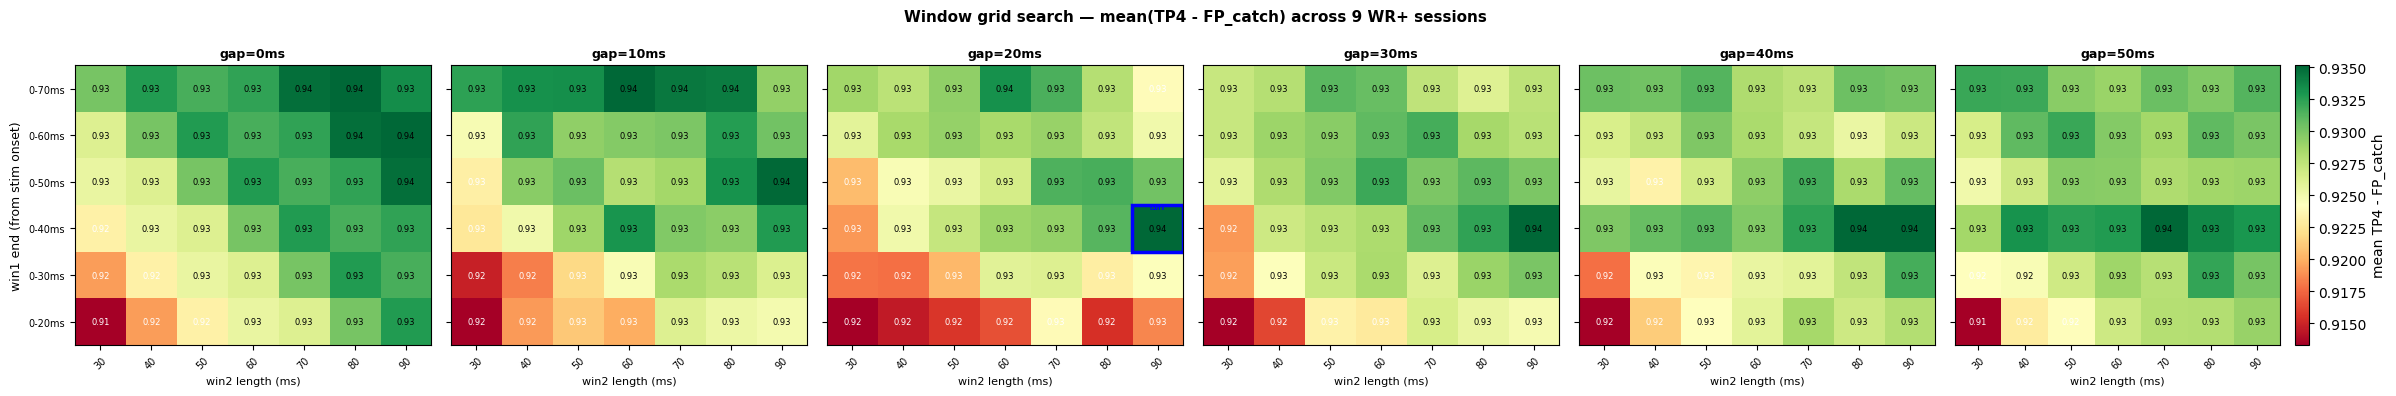

Window optimization done.


In [33]:
# -- Window optimization averaged across ALL WR+ sessions --------------------
# For each (win1, gap, win2_length): compute max(TP4 - FP_catch) on each
# WR+ session, then average across sessions.
# Uses fast trial-level scoring (no continuous session scoring).

from itertools import product as iproduct

WIN1_ENDS = [2, 3, 4, 5, 6, 7]
GAPS      = [0, 1, 2, 3, 4, 5]
WIN2_LENS = [3, 4, 5, 6, 7, 8, 9]

def fast_window_score(AP, stim4_times, catch_times, res, win1, win2, pre_bl):
    stim_mats, catch_mats = [], []
    for t in stim4_times:
        m = extract_two_window_matrix(AP, t, res, win1, win2, pre_bl)
        if m is not None: stim_mats.append(m)
    for t in catch_times:
        m = extract_two_window_matrix(AP, t, res, win1, win2, pre_bl)
        if m is not None: catch_mats.append(m)
    if len(stim_mats) < 2:
        return np.nan, np.nan, np.nan
    stim_stack  = np.stack([zscore_vector(flatten(m)) for m in stim_mats])
    catch_stack = np.stack([zscore_vector(flatten(m)) for m in catch_mats])
    catch_mean  = catch_stack.mean(axis=0) if len(catch_stack) > 0 else None
    # LOO scores for stim trials
    stim_scores = []
    for i in range(len(stim_stack)):
        keep = [j for j in range(len(stim_stack)) if j != i]
        tmpl = stim_stack[keep].mean(axis=0)
        if catch_mean is not None: tmpl = tmpl - catch_mean
        tmpl = zscore_vector(tmpl)
        v = stim_stack[i]
        stim_scores.append(float(np.dot(v, tmpl) /
                           (np.linalg.norm(v)*np.linalg.norm(tmpl)+1e-10)))
    # Full template scores for catch
    tmpl_full = stim_stack.mean(axis=0)
    if catch_mean is not None: tmpl_full = tmpl_full - catch_mean
    tmpl_full = zscore_vector(tmpl_full)
    catch_scores = [float(np.dot(v, tmpl_full) /
                         (np.linalg.norm(v)*np.linalg.norm(tmpl_full)+1e-10))
                   for v in catch_stack]
    stim_scores  = np.array(stim_scores)
    catch_scores = np.array(catch_scores) if catch_scores else np.array([])
    # Best threshold = max(TP4 - FP_catch)
    thresholds = np.unique(np.concatenate([stim_scores, catch_scores]))
    best, best_tp4, best_fpc = -np.inf, 0.0, 0.0
    for thr in thresholds:
        tp4 = float(np.mean(stim_scores >= thr))
        fpc = float(np.mean(catch_scores >= thr)) if len(catch_scores) > 0 else 0.0
        if tp4 - fpc > best:
            best, best_tp4, best_fpc = tp4-fpc, tp4, fpc
    return best, best_tp4, best_fpc

# ── Load all WR+ sessions ────────────────────────────────────────────────────
wrp_sessions = [r for r in all_results['matrix_cosine'] if r.get('group') == 'WR+']
print(f'WR+ sessions: {len(wrp_sessions)}')

session_data = []  # cache AP_w, Stim_w, Catch_w per session
for r_ref in wrp_sessions:
    path = r_ref['path']
    with NWBHDF5IO(path, 'r') as io:
        nwb   = io.read()
        tr    = nwb.trials.to_dataframe().copy()
        areas = nwb.units['Target_area'].data[:]
        areas = np.array([a.decode() if isinstance(a,(bytes,bytearray)) else a
                          for a in areas])
        sp_w  = [np.asarray(nwb.units['spike_times'][i])
                 for i in np.where(areas == THIS_AREA)[0]]
        try:
            et_obj  = nwb.processing['behavior']['BehavioralEvents']['EngagedTrials']
            et_ts   = np.array(et_obj.timestamps[:])
            et_data = np.array(et_obj.data[:])
            t_max_w = float(et_ts[et_data==1].max()) if (et_data==1).any() else np.inf
        except Exception:
            t_max_w = np.inf
    if t_max_w < np.inf:
        tr   = tr[tr['start_time'] < t_max_w].copy()
        sp_w = [s[s < t_max_w] for s in sp_w]
    t1_w     = float(tr['stop_time'].max())
    n_bins_w = int(np.round(t1_w * AP_Bin_Res))
    edges_w  = np.linspace(0.0, n_bins_w * Bin_size, n_bins_w + 1)
    AP_w = np.zeros((len(sp_w), n_bins_w), dtype=np.float32)
    for k, st in enumerate(sp_w):
        counts, _ = np.histogram(st, bins=edges_w)
        AP_w[k] = counts
    stim_sel = tr['whisker_stim_time'].notna() & tr['whisker_stim_amplitude'].isin(amps_stim)
    Stim_w = {a: np.sort(tr.loc[stim_sel & (tr['whisker_stim_amplitude']==a),
                                'whisker_stim_time'].to_numpy()) for a in amps_stim}
    if 'no_stim' in tr.columns and 'no_stim_time' in tr.columns:
        Catch_w = np.sort(tr.loc[tr['no_stim'].astype(bool) &
                                 tr['no_stim_time'].notna(),
                                 'no_stim_time'].to_numpy())
    else:
        Catch_w = np.array([])
    session_data.append({'AP': AP_w, 'stim4': Stim_w[4], 'catch': Catch_w,
                         'name': path.split('/')[-1][:30]})
    print(f'  {path.split("/")[-1][:35]:35s} | {len(sp_w):2d} units | '
          f'amp4: {len(Stim_w[4]):3d} | catch: {len(Catch_w):3d}')

# ── Grid search ──────────────────────────────────────────────────────────────
combos = [(w1e, gap, w2l)
          for w1e, gap, w2l in iproduct(WIN1_ENDS, GAPS, WIN2_LENS)
          if w1e + gap + w2l <= 25]
print(f'\nTesting {len(combos)} combinations on {len(session_data)} sessions...')

# scores_all[combo_idx][sess_idx] = (score, tp4, fpc)
scores_matrix = np.full((len(combos), len(session_data)), np.nan)
tp4_matrix    = np.full((len(combos), len(session_data)), np.nan)
fpc_matrix    = np.full((len(combos), len(session_data)), np.nan)

for ci, (w1e, gap, w2l) in enumerate(combos):
    win1 = (0, w1e); win2 = (w1e+gap, w1e+gap+w2l)
    for si, sd in enumerate(session_data):
        sc, tp4, fpc = fast_window_score(
            sd['AP'], sd['stim4'], sd['catch'],
            AP_Bin_Res, win1, win2, CD_PRE_BASELINE
        )
        scores_matrix[ci, si] = sc
        tp4_matrix[ci, si]    = tp4
        fpc_matrix[ci, si]    = fpc

# Mean across sessions (ignore nan)
mean_scores = np.nanmean(scores_matrix, axis=1)
mean_tp4    = np.nanmean(tp4_matrix,    axis=1)
mean_fpc    = np.nanmean(fpc_matrix,    axis=1)
std_scores  = np.nanstd(scores_matrix,  axis=1, ddof=1)

# Sort by mean score
order = np.argsort(-mean_scores)
results_grid = [{'win1': (0, combos[i][0]),
                 'win2': (combos[i][0]+combos[i][1],
                          combos[i][0]+combos[i][1]+combos[i][2]),
                 'w1e': combos[i][0], 'gap': combos[i][1], 'w2l': combos[i][2],
                 'score': mean_scores[i], 'score_sd': std_scores[i],
                 'tp4': mean_tp4[i], 'fpc': mean_fpc[i]}
                for i in order]

print(f'\n{"win1":12s}  {"win2":15s}  {"TP4":6s}  {"FP_catch":8s}  {"mean score":10s}  {"SD":6s}')
for r in results_grid[:10]:
    w1ms = tuple(t*10 for t in r['win1'])
    w2ms = tuple(t*10 for t in r['win2'])
    print(f'{str(w1ms):12s}  {str(w2ms):15s}  {r["tp4"]:.3f}   {r["fpc"]:.3f}  '
          f'   {r["score"]:.3f}       {r["score_sd"]:.3f}')

curr_w1 = tuple(CD_WINDOWS_2[0]); curr_w2 = tuple(CD_WINDOWS_2[1])
curr = next((r for r in results_grid
             if r['win1']==curr_w1 and r['win2']==curr_w2), None)
if curr:
    rank = next(i+1 for i,r in enumerate(results_grid)
                if r['win1']==curr_w1 and r['win2']==curr_w2)
    print(f'\nCurrent {tuple(t*10 for t in curr_w1)}ms / {tuple(t*10 for t in curr_w2)}ms  '
          f'score={curr["score"]:.3f}+/-{curr["score_sd"]:.3f}  '
          f'rank=#{rank}/{len(results_grid)}')

# ── Heatmap: mean score ───────────────────────────────────────────────────────
fig, axes = plt.subplots(1, len(GAPS), figsize=(4*len(GAPS), 4), sharey=True)
fig.suptitle(f'Window grid search — mean(TP4 - FP_catch) across {len(session_data)} WR+ sessions',
             fontweight='bold', fontsize=11)
for ax, gap in zip(axes, GAPS):
    sub = [r for r in results_grid if r['gap'] == gap]
    mat = np.full((len(WIN1_ENDS), len(WIN2_LENS)), np.nan)
    for r in sub:
        if r['w1e'] in WIN1_ENDS and r['w2l'] in WIN2_LENS:
            mat[WIN1_ENDS.index(r['w1e']),
                WIN2_LENS.index(r['w2l'])] = r['score']
    vmin = np.nanmin(mat) if not np.all(np.isnan(mat)) else 0.0
    vmax = np.nanmax(mat) if not np.all(np.isnan(mat)) else 1.0
    im = ax.imshow(mat, aspect='auto', origin='lower',
                   vmin=vmin, vmax=vmax, cmap='RdYlGn')
    ax.set_xticks(range(len(WIN2_LENS)))
    ax.set_xticklabels([f'{v*10}' for v in WIN2_LENS], fontsize=7, rotation=45)
    ax.set_yticks(range(len(WIN1_ENDS)))
    ax.set_yticklabels([f'0-{v*10}ms' for v in WIN1_ENDS], fontsize=7)
    ax.set_title(f'gap={gap*10}ms', fontweight='bold', fontsize=9)
    ax.set_xlabel('win2 length (ms)', fontsize=8)
    for ri in range(len(WIN1_ENDS)):
        for ci in range(len(WIN2_LENS)):
            v = mat[ri, ci]
            if not np.isnan(v):
                ax.text(ci, ri, f'{v:.2f}', ha='center', va='center',
                        fontsize=6,
                        color='white' if v < (vmin+vmax)/2 else 'black')
    curr_gap = CD_WINDOWS_2[1][0] - CD_WINDOWS_2[0][1]
    if gap == curr_gap:
        cw1e = CD_WINDOWS_2[0][1]
        cw2l = CD_WINDOWS_2[1][1] - CD_WINDOWS_2[1][0]
        if cw1e in WIN1_ENDS and cw2l in WIN2_LENS:
            ri = WIN1_ENDS.index(cw1e); ci = WIN2_LENS.index(cw2l)
            ax.add_patch(plt.Rectangle((ci-.5, ri-.5), 1, 1,
                         fill=False, edgecolor='blue', lw=2.5))
            ax.text(ci, ri+0.42, 'curr', ha='center',
                    fontsize=5, color='blue', fontweight='bold')
axes[0].set_ylabel('win1 end (from stim onset)', fontsize=9)
plt.colorbar(im, ax=axes[-1], label='mean TP4 - FP_catch',
             fraction=0.046, pad=0.04)
plt.tight_layout()
plt.show()
print('Window optimization done.')